<a href="https://colab.research.google.com/github/Kaewkloaw/NCDs-prediction/blob/main/CPE391.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Setting

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


# Load Data

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/CPE391/Book1.xlsx"
sheets = pd.read_excel(file_path, sheet_name=None)

first_sheet_name = list(sheets.keys())[0]

# Adding prefix each sheet expect SubjectID column
merged_df = sheets[first_sheet_name].rename(
    columns={col: f"{first_sheet_name}_{col}" for col in sheets[first_sheet_name].columns if col != 'SubjectID'}
)

for name, df in sheets.items():
    if name != first_sheet_name:
        df_renamed = df.rename(
            columns={col: f"{name}_{col}" for col in df.columns if col != 'SubjectID'}
        )
        merged_df = pd.merge(merged_df, df_renamed, on='SubjectID', how='outer')

# Determine the first column is SubjectID
cols = ['SubjectID'] + [col for col in merged_df.columns if col != 'SubjectID']
merged_df = merged_df[cols]
merged_df = merged_df.sort_values(by='Sheet1_No')
merged_df = merged_df.reset_index(drop=True)
merged_df = merged_df.drop(columns=['Sheet1_No','Sheet2_No', 'Sheet3_No', 'Sheet4_No', 'Sheet5_No' ])

# Save
merged_df.to_excel("/content/drive/MyDrive/CPE391/merged_df.xlsx", index=False)

# Show head of merged_df
merged_df.head()

,SubjectID,Sheet1_House Type,Sheet1_Gender,Sheet1_Birthday,Sheet1_Age,Sheet1_Number of residents,Sheet1_Height,Sheet1_Body weight,Sheet1_Stride（cm),Sheet1_Medical history,Sheet1_Disease name,Sheet1_Regular hospital consultation,Sheet1_Antihypertensive,Sheet1_Antidiabetic drug,Sheet1_Other,Sheet1_Smoking,Sheet1_Drinking,Sheet1_Family composition of living together,Sheet1_Hobby,Sheet1_Walking Per Day (minutes),Sheet1_Community,Sheet1_Everyday\nWith or without weight measurement,Sheet1_Everyday With or without blood pressure measurement,Sheet1_Whether or not to use a pedometer on a daily basis,Sheet1_One-legged standing test with eyes open（right）,Sheet1_One-legged standing test with eyes open（left）,Sheet1_Locomotive,Sheet2_Date confirmed\n,Sheet2_Appetite,Sheet2_Eating habit,Sheet2_Preference,Sheet2_Sleep,Sheet2_Anxiety about health,Sheet2_Anxiety about forgetfulness,Sheet2_Walking,Sheet2_life,Sheet2_social,Sheet2_food,Sheet3_Date confirmed,Sheet3_Visuospatial cognitive,Sheet3_Remember,Sheet3_use hint,Sheet3_Reading,Sheet3_Calculation,Sheet4_inspection record,Sheet4_Inspection date,Sheet4_Total cholesterol,Sheet4_LDL cholesterol,Sheet4_HDL cholesterol,Sheet4_Urea nitrogen,Sheet4_Creatinine,Sheet4_Uric acid,Sheet4_Blood sugar,Sheet4_HbA1c,Sheet4_AST,Sheet4_ALT,Sheet4_LDH,Sheet4_Na,Sheet4_K,Sheet4_ECG abnormalities,Sheet4_Triglyceride,Sheet4_Total protein,Sheet4_Albumin,Sheet5_Health status,Sheet5_Biological function,Sheet5_Exercise function,Sheet5_Nutrition,Sheet5_Cognitive function,Sheet5_Fall,Sheet5_High blood pressure,Sheet5_Arrhythmia,Sheet5_Osteoporosis,Sheet5_Diabetes mellitus,Sheet5_Exercise guidance,Sheet5_Nutrition guidance,Sheet5_Life guidance
0,cefoxSR1707004101,Housing complex,Female,1946-09-26,74,3,145.0,39.0,35.0,presence,High blood pressure,with,Amlodipine,NaN,"Lipitor, Mysley, Mediconic Acid",no,no,"Spouse, daughter",Handicraft,60,Participating in a handicraft class (once a week),with,without,not,normal,normal,NaN,2020-11-25,high,3,light,normal,medium,medium,normal,normal,normal,normal,2020-12-05,2.0,2,yes,3.0,2.0,absence,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,good,good,good,good,good,Yes,Yes,Nothing,Nothing,Nothing,Aggressive exercise,Nothing,Guidance to enhance visuospatial cognitive function
1,cefoxSR1707003701,Housing complex,Female,1947-07-22,73,2,155.0,50.0,44.0,presence,"Lung cancer,Diabetes mellitus",with,NaN,"Tenelia,Metoformin hydrochloride,Repaglinide,","Bezafibrate, Febrik, Estarosam",no,no,Spouse only,0,60,Wife of the housing complex,without,with,not,NaN,NaN,NaN,2020-11-23,high,3,light,normal,medium,medium,normal,normal,normal,normal,2020-12-05,3.0,3,no,3.0,3.0,presence,2020-11-29,150,86,39,­,1.11,6,108.0,6.2,24,20,112,­,­,NaN,153,7.7,5,good,good,Observation required,Observation required,good,Yes,Nothing,Nothing,Yes,Yes,Mild exercise,Nutritional guidance for improving eating habits,Nothing
2,cefoxSR1707005101,Housing complex,Female,1944-08-01,76,2,154.0,56.5,26.9,presence,High blood pressure,with,Amlodipine,NaN,Tsumura Kakkonto extract,no,no,Living with son,0,60,NaN,without,with,use,normal,normal,Abnormal,2020-11-25,medium,3,light,normal,medium,medium,normal,normal,normal,normal,2020-12-05,1.0,2,no,3.0,3.0,presence,2020-08-04,260,163,68,20.3,0.75,5.3,NaN,­,18,12,175,142,3.5,NaN,­,7.2,­,good,good,Observation required,Observation required,Observation required,Yes,Yes,Nothing,Nothing,Nothing,Mild exercise,Nutritional guidance for improving eating habits,Guidance to enhance visuospatial cognitive function
3,cefoxSR1707003501,Housing complex,Man,1939-08-25,81,2,158.0,65.0,32.3,presence,"Kidney disease,High blood pressure",with,"Olmesartan, Nifedipine",NaN,"Donepezil, Famotidine, Lepamidine,Ttriazolam",no,yes,Spouse only,0,0,NaN,without,without,not,abnormal,normal,Abnormal,2020-11-25,high,3,sweet,normal,high,medium,normal,somewhat problematic,normal,normal,2020-12-05,2.0,2,no,3.0,2.0,presence,2020-09-02,­,­,­,37.5,3.57,4.5,NaN,5,­,­,­,147,4.85,NaN,­,6.3,4.2,Observation requir

# Pre-Processing

In [ ]:
merged_df.shape

(53, 76)

In [ ]:
import pandas as pd

def create_sheet_dfs(merged_df, sheets):
    sheet_dfs = {}
    for sheet_name in sheets:
        cols = ['SubjectID'] + [col for col in merged_df.columns if col.startswith(f"{sheet_name}_")]
        sheet_dfs[sheet_name] = merged_df[cols]
    return sheet_dfs

# List of subset of dataframe
sheets = ["Sheet1", "Sheet2", "Sheet3", "Sheet4", "Sheet5"]

# Create the subset of dataframe
sheet_dfs = create_sheet_dfs(merged_df, sheets)

# Create variables for easy use involves assigning
sheet1 = sheet_dfs["Sheet1"]
sheet2 = sheet_dfs["Sheet2"]
sheet3 = sheet_dfs["Sheet3"]
sheet4 = sheet_dfs["Sheet4"]
sheet5 = sheet_dfs["Sheet5"]

### sheet1

In [ ]:
sheet1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 27 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   SubjectID                                                   53 non-null     object        
 1   Sheet1_House Type                                           53 non-null     object        
 2   Sheet1_Gender                                               53 non-null     object        
 3   Sheet1_Birthday                                             53 non-null     datetime64[ns]
 4   Sheet1_Age                                                  53 non-null     int64         
 5   Sheet1_Number of residents                                  53 non-null     int64         
 6   Sheet1_Height                                               53 non-null     float64       
 7   Sheet1_Body weight          

#### drop

In [ ]:
for column in sheet1.columns:
    if column != "SubjectID":
        unique_values = sheet1[column].dropna().unique()
        if len(unique_values) == 1:
            print(f"Column '{column}' has a single unique value: {unique_values[0]}")

Column 'Sheet1_Smoking' has a single unique value: no
Column 'Sheet1_One-legged standing test with eyes open（left）' has a single unique value: normal
Column 'Sheet1_Locomotive' has a single unique value: Abnormal


In [ ]:
# Drop columns that contain only one unique value
OneUniqueValue_list = ['Sheet1_Smoking', 'Sheet1_One-legged standing test with eyes open（left）', 'Sheet1_Locomotive']
sheet1 = sheet1.drop(columns=OneUniqueValue_list)
# Drop unnecessary columns
sheet1 = sheet1.drop(columns='Sheet1_Birthday') # Age is more useful than Birthday

#### unique value

In [ ]:
sheet1['Sheet1_House Type'].value_counts()

,count
Sheet1_House Type,
Housing complex,50
Detached house,3


In [ ]:
sheet1['Sheet1_Gender'].value_counts()

,count
Sheet1_Gender,
Female,33
Man,20


In [ ]:
sheet1['Sheet1_Age'].value_counts()

,count
Sheet1_Age,
71,7
81,5
80,5
69,4
76,4
74,3
70,3
85,2
73,2


In [ ]:
sheet1['Sheet1_Number of residents'].value_counts()

,count
Sheet1_Number of residents,
2,29
1,19
3,4
4,1


In [ ]:
sheet1['Sheet1_Height'].value_counts()

,count
Sheet1_Height,
150.0,5
158.0,5
156.0,4
168.0,4
161.0,4
154.0,3
160.0,3
159.0,3
165.0,2


In [ ]:
sheet1['Sheet1_Medical history'].value_counts()

,count
Sheet1_Medical history,
presence,48
absence,5


In [ ]:
sheet1['Sheet1_Regular hospital consultation'].value_counts()

,count
Sheet1_Regular hospital consultation,
with,48
without,5


In [ ]:
sheet1['Sheet1_Drinking'].value_counts()

,count
Sheet1_Drinking,
no,36
yes,17


In [ ]:
sheet1['Sheet1_Family composition of living together'].unique()

array(['Spouse, daughter', 'Spouse only', 'Living with son',
       'Living alone', 'Spouse, brother', 'Spouse, daughter, grandchild',
       'Living with daughter'], dtype=object)

In [ ]:
sheet1['Sheet1_Alone_or_Not'] = sheet1['Sheet1_Family composition of living together'].apply(
    lambda x: 'alone' if x == 'Living alone' else 'not alone'
)

In [ ]:
sheet1['Sheet1_Alone_or_Not'].value_counts()

,count
Sheet1_Alone_or_Not,
not alone,32
alone,21


In [ ]:
# Drop 'Sheet1_Family composition of living together'
sheet1 = sheet1.drop(columns='Sheet1_Family composition of living together')

In [ ]:
sheet1['Sheet1_Hobby'].value_counts()

,count
Sheet1_Hobby,
0,31
Horticulture,4
Handicraft,3
handicraft,3
Caring for a dog,3
dog-walking,2
cooking,1
Caring for cats,1
Walk around,1


In [ ]:
sheet1['Sheet1_Hobby'].value_counts()
print(sheet1['Sheet1_Hobby'].unique())


['Handicraft' 0 'cooking' 'Caring for cats' 'Caring for a dog'
 'Horticulture' 'Walk around' 'karaoke' 'handicraft' 'bicycle'
 'cooking,walk' 'gardening' 'dog-walking']


In [ ]:
sheet1['Sheet1_Hobby'] = sheet1['Sheet1_Hobby'].apply(
    lambda x: 'nothave' if x == 0 else 'have'
)

In [ ]:
sheet1['Sheet1_Hobby'].value_counts()

,count
Sheet1_Hobby,
nothave,31
have,22


In [ ]:
sheet1['Sheet1_Walking Per Day (minutes)'].value_counts()

,count
Sheet1_Walking Per Day (minutes),
0,22
30,14
60,11
50,3
Walking:,2
30\nCycling,1


#### Change value

In [ ]:
# Convert column to string first (to avoid errors)
col = sheet1['Sheet1_Walking Per Day (minutes)'].astype(str)

# 1) Fix "30\nCycling" → "30"
col = col.str.replace(r'\D+', '', regex=True)   # remove all non-digits

# Now convert numbers from string to numeric
col = pd.to_numeric(col, errors='coerce')

# 2) Compute the mean **after cleaning**
mean_value = col.mode()

# 3) Replace the original "Walking:" with the mean
# ("Walking:" became NaN after regex removal)
col = col.fillna(mean_value)

# Save back to dataframe
sheet1['Sheet1_Walking Per Day (minutes)'] = col


In [ ]:
sheet1['Sheet1_Walking Per Day (minutes)'].value_counts()

,count
Sheet1_Walking Per Day (minutes),
0.0,22
30.0,15
60.0,11
50.0,3


In [ ]:
sheet1.columns

Index(['SubjectID', 'Sheet1_House Type', 'Sheet1_Gender', 'Sheet1_Age',
       'Sheet1_Number of residents', 'Sheet1_Height', 'Sheet1_Body weight',
       'Sheet1_Stride（cm)', 'Sheet1_Medical history', 'Sheet1_Disease name',
       'Sheet1_Regular hospital consultation', 'Sheet1_Antihypertensive',
       'Sheet1_Antidiabetic drug', 'Sheet1_Other', 'Sheet1_Drinking',
       'Sheet1_Hobby', 'Sheet1_Walking Per Day (minutes)', 'Sheet1_Community',
       'Sheet1_Everyday\nWith or without weight measurement',
       'Sheet1_Everyday With or without blood pressure measurement',
       'Sheet1_Whether or not to use a pedometer on a daily basis',
       'Sheet1_One-legged standing test with eyes open（right）',
       'Sheet1_Alone_or_Not'],
      dtype='object')

In [ ]:
sheet1['Sheet1_Everyday With or without blood pressure measurement'].value_counts()

,count
Sheet1_Everyday With or without blood pressure measurement,
without,32
with,21


In [ ]:
sheet1[ 'Sheet1_Whether or not to use a pedometer on a daily basis'].value_counts()

,count
Sheet1_Whether or not to use a pedometer on a daily basis,
not,38
use,15


#### feature BMI Level

In [ ]:
sheet1["Sheet1_BMI"] = sheet1["Sheet1_Body weight"] / (sheet1["Sheet1_Height"] / 100) ** 2
bins = [0, 18.5, 25, 30, 100]   # upper bound high enough
labels = ["Underweight", "Normal", "Overweight", "Obese"]
sheet1["Sheet1_BMI Level"] = pd.cut(sheet1["Sheet1_BMI"], bins=bins, labels=labels, right=False)

#### fill missing value

In [ ]:
common_cols = sheet1.columns.intersection(merged_df.columns)
sheet1[common_cols].isnull().sum()[merged_df[common_cols].isnull().sum() != 0]

,0
Sheet1_Stride（cm),26
Sheet1_Disease name,1
Sheet1_Antihypertensive,33
Sheet1_Antidiabetic drug,48
Sheet1_Other,37
Sheet1_Community,33
Sheet1_One-legged standing test with eyes open（right）,24


Sheet1_Stride（cm)

In [ ]:
sheet1['Sheet1_Stride（cm)'].value_counts()

,count
Sheet1_Stride（cm),
35.0,3
30.0,3
26.9,2
52.6,2
32.0,2
58.7,2
44.0,1
46.0,1
35.5,1


In [ ]:
# Select numeric columns
numeric_cols = ["Sheet1_Height", "Sheet1_Age", "Sheet1_Body weight", "Sheet1_BMI", "Sheet1_Stride（cm)"]

print(sheet1[numeric_cols].corr()["Sheet1_Stride（cm)"])

Sheet1_Height         0.707161
Sheet1_Age           -0.327759
Sheet1_Body weight    0.184494
Sheet1_BMI           -0.337881
Sheet1_Stride（cm)     1.000000
Name: Sheet1_Stride（cm), dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
predictors = ["Sheet1_Height", "Sheet1_Age", "Sheet1_BMI"]  # numeric predictors
train = sheet1[sheet1["Sheet1_Stride（cm)"].notna()]
test  = sheet1[sheet1["Sheet1_Stride（cm)"].isna()]

# Train regression model
model = LinearRegression()
model.fit(train[predictors], train["Sheet1_Stride（cm)"])

# Predict missing values
sheet1.loc[sheet1["Sheet1_Stride（cm)"].isna(), "Sheet1_Stride（cm)"] = model.predict(test[predictors])


Sheet1_Disease name

In [ ]:
sheet1['Sheet1_Disease name'].value_counts()

,count
Sheet1_Disease name,
High blood pressure,30
0,4
High blood pressure、Diabetes mellitus,2
"Kidney disease,High blood pressure",1
"Lung cancer,Diabetes mellitus",1
Cancer (during chemotherapy),1
Hyperlipidemia,1
"High blood pressure,Diabetes mellitus",1
Osteoarthritis of both knees (after surgery),1


In [ ]:
import pandas as pd
import unicodedata
from sklearn.preprocessing import MultiLabelBinarizer

# -----------------------------
# ฟังก์ชันทำความสะอาดแต่ละโรค
# -----------------------------
mapping = {
    'Diabetes mellitus': 'Diabetes',
}

def clean_text(x):
    if not isinstance(x, str):
        return ''
    x = unicodedata.normalize('NFKC', x)      # ทำ normalize unicode เช่น full-width
    x = x.replace('\u200b', '')               # ลบ zero-width space
    x = x.strip()                             # ตัดช่องว่างซ้าย-ขวา
    return mapping.get(x, x)                  # รวม Diabetes mellitus → Diabetes


# 1️⃣ แทน separator ต่างๆ ให้เป็น comma
sheet1['Medical_history_clean'] = (
    sheet1['Sheet1_Disease name']
    .astype(str)
    .str.replace('、', ',', regex=False)
    .str.replace(',,', ',', regex=False)
)

# 2️⃣ แยกค่าเป็น list + strip + clean + ลบช่องว่าง
sheet1['Medical_history_list'] = (
    sheet1['Medical_history_clean']
    .str.split(',')
    .apply(lambda items: [clean_text(i) for i in items if clean_text(i) != ''])
)

# 3️⃣ แทนค่า non-string หรือ '0' เป็น list ว่าง
sheet1['Medical_history_list'] = sheet1['Medical_history_list'].apply(
    lambda x: x if isinstance(x, list) and x != ['0'] else []
)

# 4️⃣ Multi-hot encoding
mlb = MultiLabelBinarizer()
multi_hot = pd.DataFrame(
    mlb.fit_transform(sheet1['Medical_history_list']),
    columns=mlb.classes_,
    index=sheet1.index
)

# 5️⃣ เพิ่ม multi-hot columns ลงใน sheet1 เดิม โดยไม่ลบ column อื่น
sheet1 = pd.concat([sheet1, multi_hot], axis=1)

# 6️⃣ ลบ column ชั่วคราว
sheet1.drop(columns=['Medical_history_clean', 'Medical_history_list'], inplace=True)

# 7️⃣ ลบคอลัมน์ต้นฉบับ
sheet1.drop(columns=['Sheet1_Disease name'], inplace=True)


In [ ]:
# from sklearn.preprocessing import MultiLabelBinarizer
# # 1️⃣ แทน separator ต่างๆ ให้เป็น comma
# sheet1['Medical_history_clean'] = sheet1['Sheet1_Disease name'].str.replace('、', ',', regex=False).str.replace(',,', ',', regex=False)

# # 2️⃣ แยกค่าออกเป็น list
# sheet1['Medical_history_list'] = sheet1['Medical_history_clean'].str.split(',')

# # 3️⃣ แทนค่า non-string หรือ '0' เป็น list ว่าง
# sheet1['Medical_history_list'] = sheet1['Medical_history_list'].apply(lambda x: x if isinstance(x, list) and x[0] != '0' else [])

# # 4️⃣ Multi-hot encoding
# mlb = MultiLabelBinarizer()
# multi_hot = pd.DataFrame(mlb.fit_transform(sheet1['Medical_history_list']),
#                          columns=mlb.classes_,
#                          index=sheet1.index)

# # 5️⃣ เพิ่ม multi-hot columns ลงใน sheet1 เดิม โดยไม่ลบ column อื่น
# sheet1 = pd.concat([sheet1, multi_hot], axis=1)

# # 6️⃣ ลบ column ชั่วคราวถ้าไม่ต้องการ
# sheet1.drop(columns=['Medical_history_clean', 'Medical_history_list'], inplace=True)

# # ตรวจสอบ
# sheet1.drop(columns=['Sheet1_Disease name'], inplace=True)

Sheet1_Antihypertensive

In [ ]:
sheet1['Sheet1_Antihypertensive'].value_counts()

,count
Sheet1_Antihypertensive,
Amlodipine,5
Azilva、Amlodipine,2
Antihypertensive,2
NifedipineCR,1
"Micardis, Calblock",1
"Olmesartan, Nifedipine",1
Valsartan、Nifedipine,1
Trichlormethiazide、Amlodipine,1
Azilva、Nifedipine、Pisoprolol fumarate,1


In [ ]:
# 1️⃣ Replace separators with comma
sheet1['Antihypertensive_clean'] = sheet1['Sheet1_Antihypertensive'] \
    .str.replace('、', ',', regex=False) \
    .str.replace('，', ',', regex=False) \
    .str.replace(',,', ',', regex=False)

# 2️⃣ Split into list
sheet1['Antihypertensive_list'] = sheet1['Antihypertensive_clean'].str.split(',')

# 3️⃣ Replace non-string or '0' with empty list
sheet1['Antihypertensive_list'] = sheet1['Antihypertensive_list'].apply(
    lambda x: [i.strip() for i in x] if isinstance(x, list) and x[0] != '0' else []
)

# 4️⃣ Multi-hot encoding
mlb = MultiLabelBinarizer()
multi_hot = pd.DataFrame(
    mlb.fit_transform(sheet1['Antihypertensive_list']),
    columns=mlb.classes_,
    index=sheet1.index
)

# 5️⃣ Concatenate multi-hot columns into sheet1
sheet1 = pd.concat([sheet1, multi_hot], axis=1)

# 6️⃣ Drop temporary columns if desired
sheet1.drop(columns=['Antihypertensive_clean', 'Antihypertensive_list'], inplace=True)

Sheet1_Antidiabetic drug

In [ ]:
sheet1['Sheet1_Antidiabetic drug'].value_counts()

,count
Sheet1_Antidiabetic drug,
"Tenelia,Metoformin hydrochloride,Repaglinide,",1
Gractive,1
Metformin,1
Junuvia、Suglat,1
Glactiv,1


In [ ]:
# 1️⃣ Replace separators with comma
sheet1['Antidiabetic_clean'] = sheet1['Sheet1_Antidiabetic drug'] \
    .str.replace('、', ',', regex=False) \
    .str.replace('，', ',', regex=False) \
    .str.replace(',,', ',', regex=False)

# 2️⃣ Split into list
sheet1['Antidiabetic_list'] = sheet1['Antidiabetic_clean'].str.split(',')

# 3️⃣ Clean whitespace and handle empty or '0'
sheet1['Antidiabetic_list'] = sheet1['Antidiabetic_list'].apply(
    lambda x: [i.strip() for i in x if i.strip() != '0'] if isinstance(x, list) else []
)

# 4️⃣ Multi-hot encoding
mlb = MultiLabelBinarizer()
multi_hot = pd.DataFrame(
    mlb.fit_transform(sheet1['Antidiabetic_list']),
    columns=mlb.classes_,
    index=sheet1.index
)

# 5️⃣ Concatenate multi-hot columns into sheet1
sheet1 = pd.concat([sheet1, multi_hot], axis=1)

# 6️⃣ Drop temporary columns if not needed
sheet1.drop(columns=['Antidiabetic_clean', 'Antidiabetic_list'], inplace=True)

Sheet1_Other

In [ ]:
sheet1['Sheet1_Other'].value_counts()

,count
Sheet1_Other,
"Lipitor, Mysley, Mediconic Acid",1
"Bezafibrate, Febrik, Estarosam",1
Tsumura Kakkonto extract,1
"Donepezil, Famotidine, Lepamidine,Ttriazolam",1
"Crestor, Halcyon, Magnesium Oxide, Montelukast, Loxoprofen",1
Rivalo,1
"Loxoprofen, Rebamipide, Bersolam, Sennoside, Magmit",1
"Bezafibrate, Etizolam, Antebate",1
"Zopiclone, Full Bath Titanium",1


In [ ]:
# 1️⃣ Replace separators with comma
sheet1['Other_clean'] = sheet1['Sheet1_Other'] \
    .str.replace('、', ',', regex=False) \
    .str.replace('，', ',', regex=False) \
    .str.replace(',,', ',', regex=False)

# 2️⃣ Split into list
sheet1['Other_list'] = sheet1['Other_clean'].str.split(',')

# 3️⃣ Strip whitespace and remove empty or '0'
sheet1['Other_list'] = sheet1['Other_list'].apply(
    lambda x: [i.strip() for i in x if i.strip() != '0'] if isinstance(x, list) else []
)

# 4️⃣ Multi-hot encoding
mlb = MultiLabelBinarizer()
multi_hot = pd.DataFrame(
    mlb.fit_transform(sheet1['Other_list']),
    columns=mlb.classes_,
    index=sheet1.index
)

# 5️⃣ Concatenate multi-hot columns into sheet1
sheet1 = pd.concat([sheet1, multi_hot], axis=1)

# 6️⃣ Drop temporary columns if not needed
sheet1.drop(columns=['Other_clean', 'Other_list'], inplace=True)

Sheet1_Community

In [ ]:
sheet1['Sheet1_Community'].value_counts()

,count
Sheet1_Community,
2,34
0,7
1,6
3,6


In [ ]:
# 1️⃣ Define function to assign activity level
def activity_level(x):
    x = str(x)  # ensure string
    if x in ["Work (5 days / week)", "Work (4 days / week)", "Housing complex manager", "Helping with field work", "Helping others own field work"]:
        return "High"
    elif x in ["Handmade class（every day）", "Participating in a handicraft class (once a week)", "teacher of Karaoke", "Use of day service (once / week)"]:
        return "Medium"
    elif x in ["Stay in the room all day", "Wife of the housing complex", "0"]:
        return "Low"
    else:
        return "Unknown"

# 2️⃣ Apply function
sheet1['Sheet1_Community'] = sheet1['Sheet1_Community'].apply(activity_level)

Sheet1_One-legged standing test with eyes open（right）

In [ ]:
sheet1['Sheet1_One-legged standing test with eyes open（right）'].fillna('normal', inplace=True)
sheet1['Sheet1_One-legged standing test with eyes open（right）'].value_counts()

/tmp/ipython-input-851643887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet1['Sheet1_One-legged standing test with eyes open（right）'].fillna('normal', inplace=True)


,count
Sheet1_One-legged standing test with eyes open（right）,
normal,47
abnormal,6


In [ ]:
sheet1 = sheet1.drop(columns=["Sheet1_Antihypertensive","Sheet1_Antidiabetic drug","Sheet1_Other"], errors='ignore')

In [ ]:
sheet1.to_csv("/content/drive/MyDrive/CPE391/sheet1.csv", index=False)
sheet1.to_excel("/content/drive/MyDrive/CPE391/sheet1.xlsx", index=False)

In [ ]:
sheet1.columns

Index(['SubjectID', 'Sheet1_House Type', 'Sheet1_Gender', 'Sheet1_Age',
       'Sheet1_Number of residents', 'Sheet1_Height', 'Sheet1_Body weight',
       'Sheet1_Stride（cm)', 'Sheet1_Medical history',
       'Sheet1_Regular hospital consultation', 'Sheet1_Drinking',
       'Sheet1_Hobby', 'Sheet1_Walking Per Day (minutes)', 'Sheet1_Community',
       'Sheet1_Everyday\nWith or without weight measurement',
       'Sheet1_Everyday With or without blood pressure measurement',
       'Sheet1_Whether or not to use a pedometer on a daily basis',
       'Sheet1_One-legged standing test with eyes open（right）',
       'Sheet1_Alone_or_Not', 'Sheet1_BMI', 'Sheet1_BMI Level',
       'Benign prostatic hypplasiaer', 'Cancer (during chemotherapy)',
       'Diabetes', 'Heart disease (during stent insertion)',
       'High blood pressure', 'Hypercholesterolemia', 'Hyperlipidemia',
       'Kidney disease', 'Lung cancer', 'Lung cancer(2015surgery)',
       'Neuralgia', 'Osteoarthritis of both knees (aft

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


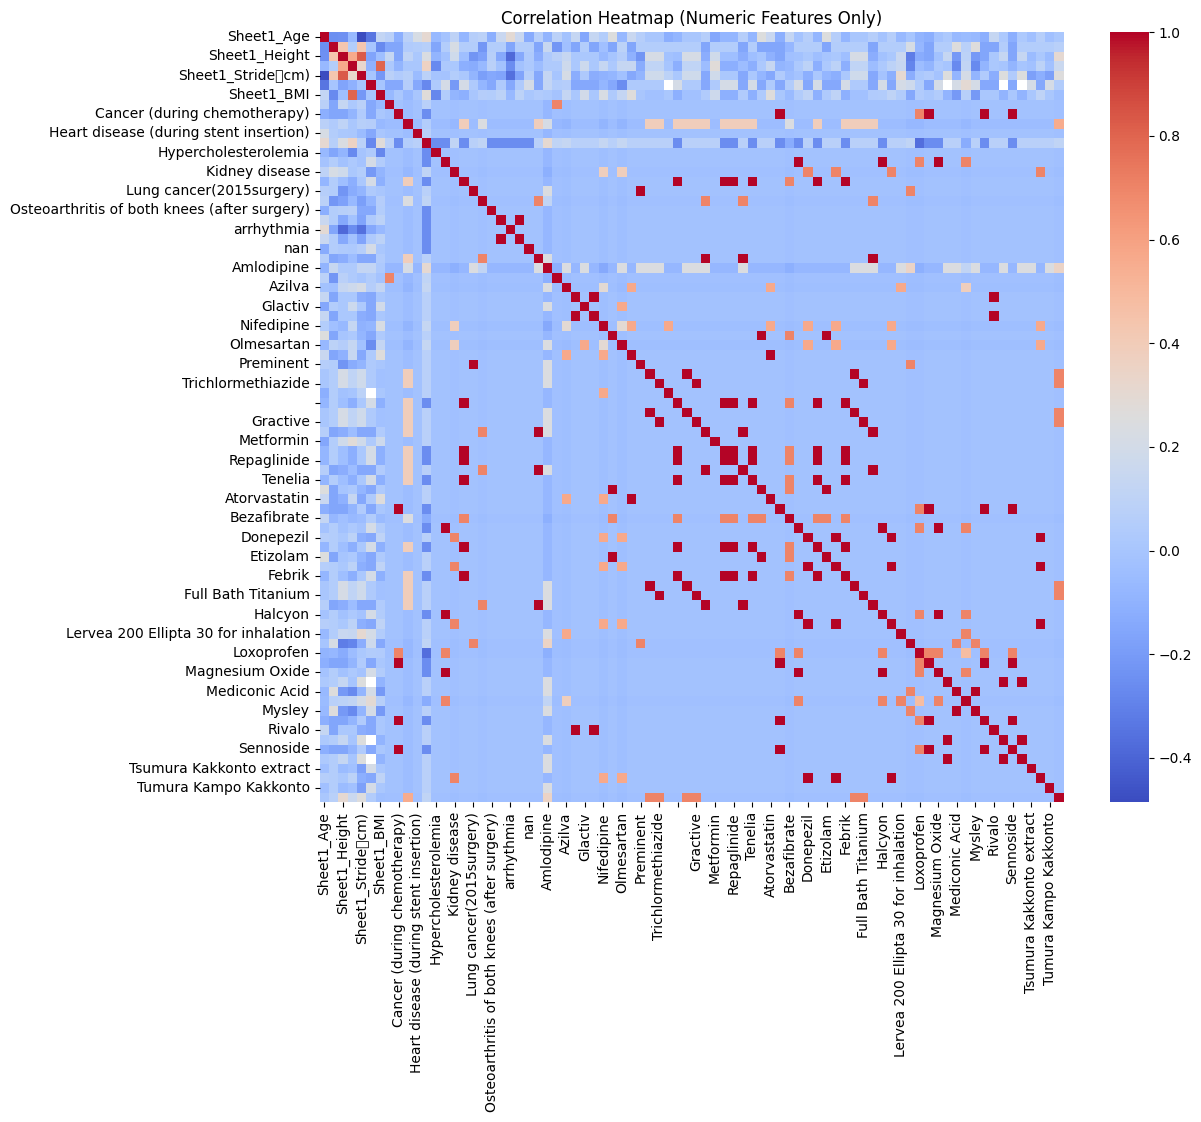

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Select only numeric columns
numeric_data = sheet1.select_dtypes(include=['int64', 'float64'])

# 2) Compute correlation matrix
corr = numeric_data.corr()

# 3) Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


Correlation with High blood pressure (>|0.2|):
Sheet1_Body weight                              0.356430
Amlodipine                                      0.308418
Sheet1_Age                                      0.306515
Sheet1_BMI                                      0.269567
Sheet1_Height                                   0.236736
Estarosam                                      -0.256330
Tenelia                                        -0.256330
Hypercholesterolemia                           -0.256330
Lung cancer                                    -0.256330
Hyperlipidemia                                 -0.256330
Uterine fibroid                                -0.256330
cerebral infarction                            -0.256330
                                               -0.256330
Magnesium Oxide                                -0.256330
Halcyon                                        -0.256330
Metoformin hydrochloride                       -0.256330
Repaglinide                             

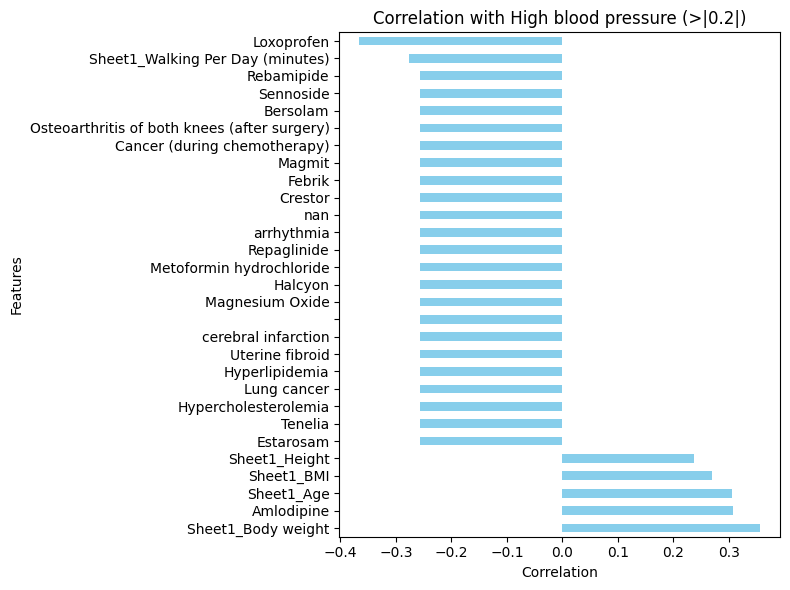


Correlation with Diabetes (>|0.2|):
Zopiclone                   0.554247
Gractive                    0.388125
Full Bath Titanium          0.388125
Trichlormethiazide          0.388125
Lung cancer                 0.388125
Febrik                      0.388125
Estarosam                   0.388125
Junuvia                     0.388125
AdalatＣＲ                    0.388125
                            0.388125
Trichlormethazide           0.388125
Gaster                      0.388125
Suglat                      0.388125
Tenelia                     0.388125
Glactiv                     0.388125
Fluvastatin                 0.388125
Repaglinide                 0.388125
Metoformin hydrochloride    0.388125
Bezafibrate                 0.241746
Neuralgia                   0.241746
Amlodipine                  0.211524
Name: Diabetes, dtype: float64


/tmp/ipython-input-2437278591.py:30: UserWarning: Glyph 65315 (\N{FULLWIDTH LATIN CAPITAL LETTER C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2437278591.py:30: UserWarning: Glyph 65330 (\N{FULLWIDTH LATIN CAPITAL LETTER R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65315 (\N{FULLWIDTH LATIN CAPITAL LETTER C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65330 (\N{FULLWIDTH LATIN CAPITAL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


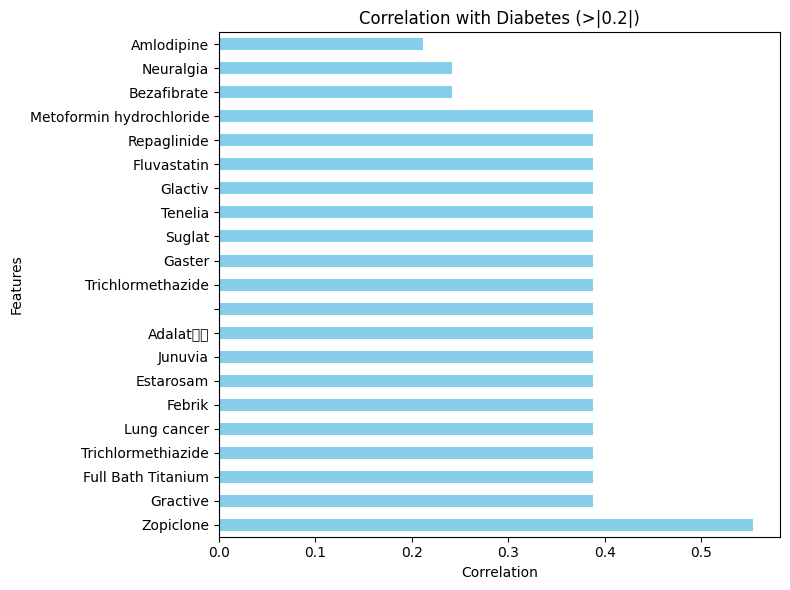

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Select numeric columns only ---
numeric_data = sheet1.select_dtypes(include=['int64', 'float64'])

# --- 2. Define target columns ---
targets = ['High blood pressure', 'Diabetes']

for target in targets:
    if target not in numeric_data.columns:
        raise ValueError(f"Column '{target}' not found in numeric data!")

    # --- 3. Compute correlation with target ---
    corr_with_target = numeric_data.corr()[target].sort_values(ascending=False)

    # --- 4. Filter correlations > 0.2 (exclude target itself) ---
    corr_filtered = corr_with_target.drop(target)
    corr_filtered = corr_filtered[corr_filtered.abs() > 0.2]

    # --- 5. Display correlation values ---
    print(f"\nCorrelation with {target} (>|0.2|):")
    print(corr_filtered)

    # --- 6. Plot horizontal bar chart ---
    corr_filtered.plot(kind='barh', figsize=(8, 6), color='skyblue')
    plt.title(f"Correlation with {target} (>|0.2|)")
    plt.xlabel("Correlation")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


### sheet2

In [ ]:
sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   SubjectID                           53 non-null     object        
 1   Sheet2_Date confirmed
              53 non-null     datetime64[ns]
 2   Sheet2_Appetite                     53 non-null     object        
 3   Sheet2_Eating habit                 53 non-null     int64         
 4   Sheet2_Preference                   53 non-null     object        
 5   Sheet2_Sleep                        53 non-null     object        
 6   Sheet2_Anxiety about health         53 non-null     object        
 7   Sheet2_Anxiety about forgetfulness  53 non-null     object        
 8   Sheet2_Walking                      53 non-null     object        
 9   Sheet2_life                         53 non-null     object        
 10  Sheet2_social               

In [ ]:
sheet2.columns

Index(['SubjectID', 'Sheet2_Date confirmed\n', 'Sheet2_Appetite',
       'Sheet2_Eating habit', 'Sheet2_Preference', 'Sheet2_Sleep',
       'Sheet2_Anxiety about health', 'Sheet2_Anxiety about forgetfulness',
       'Sheet2_Walking ', 'Sheet2_life', 'Sheet2_social ', 'Sheet2_food'],
      dtype='object')

#### drop

In [ ]:
for column in sheet2.columns:
    if column != "SubjectID":
        unique_values = sheet2[column].dropna().unique()
        if len(unique_values) == 1:
            print(f"Column '{column}' has a single unique value: {unique_values[0]}")

Column 'Sheet2_social ' has a single unique value: normal


In [ ]:
sheet2['Sheet2_social '].value_counts()

,count
Sheet2_social,
normal,53


In [ ]:
# Drop columns that contain only one unique value
OneUniqueValue_list = ['Sheet2_social ']
sheet2 = sheet2.drop(columns=OneUniqueValue_list)

In [ ]:
sheet2['Sheet2_Date confirmed\n'].value_counts()

,count
Sheet2_Date confirmed,
2020-11-30,12
2020-11-23,9
2020-12-03,9
2020-11-25,5
2020-11-28,5
2020-12-10,4
2020-12-16,3
2021-02-13,2
2021-01-06,2


In [ ]:
sheet2['Sheet2_Appetite'].value_counts()

,count
Sheet2_Appetite,
high,24
medium,20
high,9


In [ ]:
sheet2['Sheet2_Eating habit'].value_counts()

,count
Sheet2_Eating habit,
3,50
2,3


In [ ]:
sheet2['Sheet2_Preference'].value_counts()

,count
Sheet2_Preference,
light,43
sweet,9
spicy,1


In [ ]:
sheet2['Sheet2_Sleep'].value_counts()

,count
Sheet2_Sleep,
normal,33
well,11
normal,7
not sleep,2


In [ ]:
sheet2['Sheet2_Anxiety about health'].value_counts()

,count
Sheet2_Anxiety about health,
medium,44
high,6
none,3


In [ ]:
sheet2['Sheet2_Anxiety about forgetfulness'].value_counts()

,count
Sheet2_Anxiety about forgetfulness,
medium,45
high,4
none,3
high,1


In [ ]:
sheet2['Sheet2_Walking '].value_counts()

,count
Sheet2_Walking,
normal,42
somewhat problematic,6
problem,5


In [ ]:
sheet2['Sheet2_life'].value_counts()

,count
Sheet2_life,
normal,49
somewhat problematic,2
problem,2


In [ ]:
sheet2['Sheet2_food'].value_counts()

,count
Sheet2_food,
normal,48
somewhat problematic,5


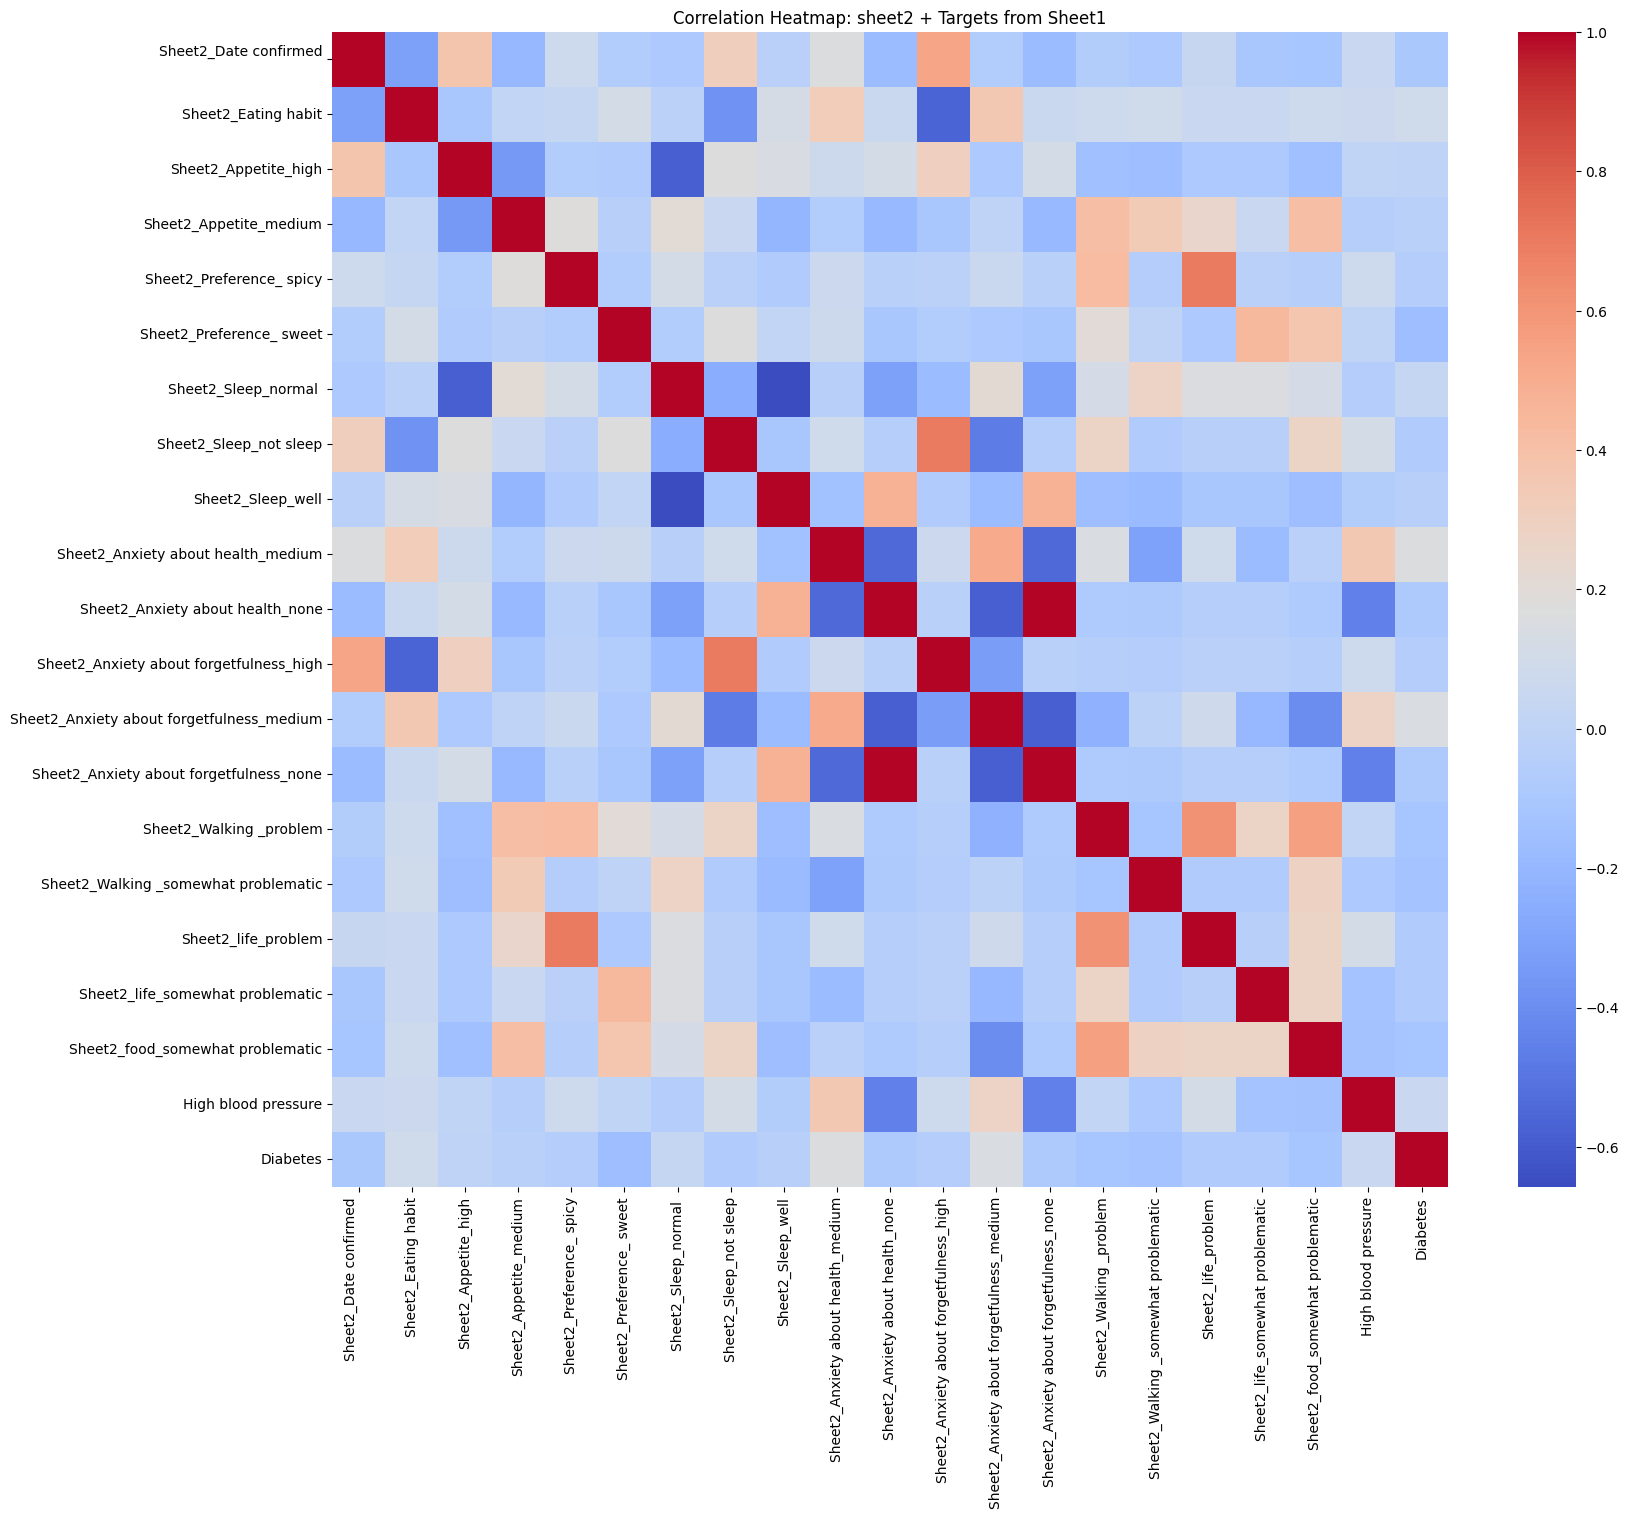

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Select sheet2 columns to include (exclude identifier/date) ---
cols_sheet2 = [col for col in sheet2.columns if col not in ['SubjectID', 'Sheet2_Date confirmed']]
data_sheet2 = sheet2[cols_sheet2].copy()

# --- 2. Encode categorical columns in sheet2 ---
data_sheet2_encoded = pd.get_dummies(data_sheet2, drop_first=True)

# --- 3. Select target columns from sheet1 ---
targets = ['High blood pressure', 'Diabetes']

# Make sure target columns exist
for t in targets:
    if t not in sheet1.columns:
        raise ValueError(f"Column '{t}' not found in sheet1!")

# Select the target columns
targets_data = sheet1[targets].copy()

# --- 4. Concatenate sheet2 + targets ---
data_combined = pd.concat([data_sheet2_encoded, targets_data], axis=1)

# --- 5. Compute correlation matrix ---
corr = data_combined.corr()

# --- 6. Plot heatmap ---
plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap: sheet2 + Targets from Sheet1")
plt.show()



Features correlated with High blood pressure (>|0.2|):
Sheet2_Anxiety about health_medium           0.355688
Sheet2_Anxiety about forgetfulness_medium    0.275629
Sheet2_Anxiety about health_none            -0.452769
Sheet2_Anxiety about forgetfulness_none     -0.452769
Name: High blood pressure, dtype: float64


/tmp/ipython-input-3695168136.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


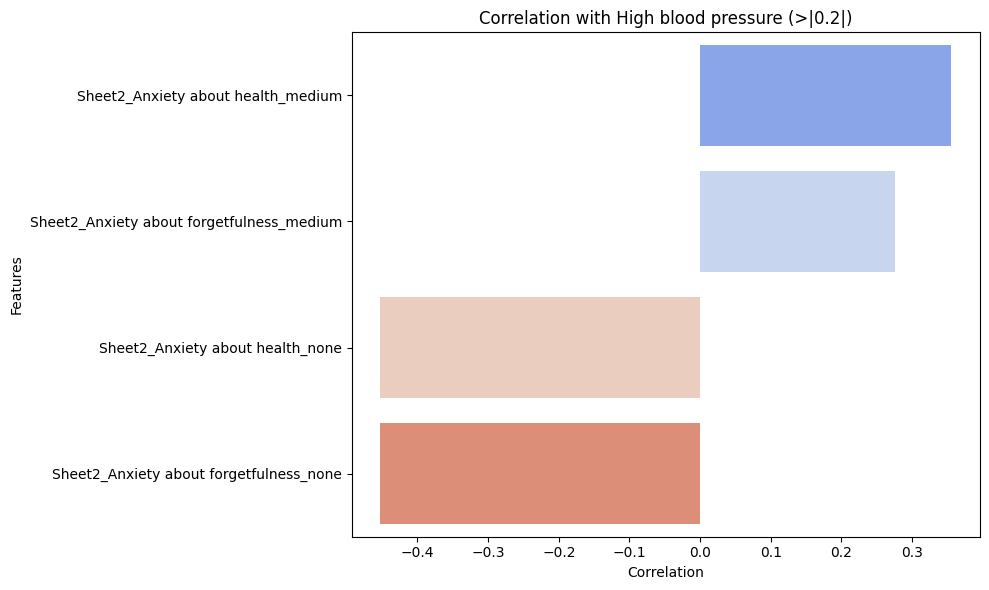


Features correlated with Diabetes (>|0.2|):
Series([], Name: Diabetes, dtype: float64)


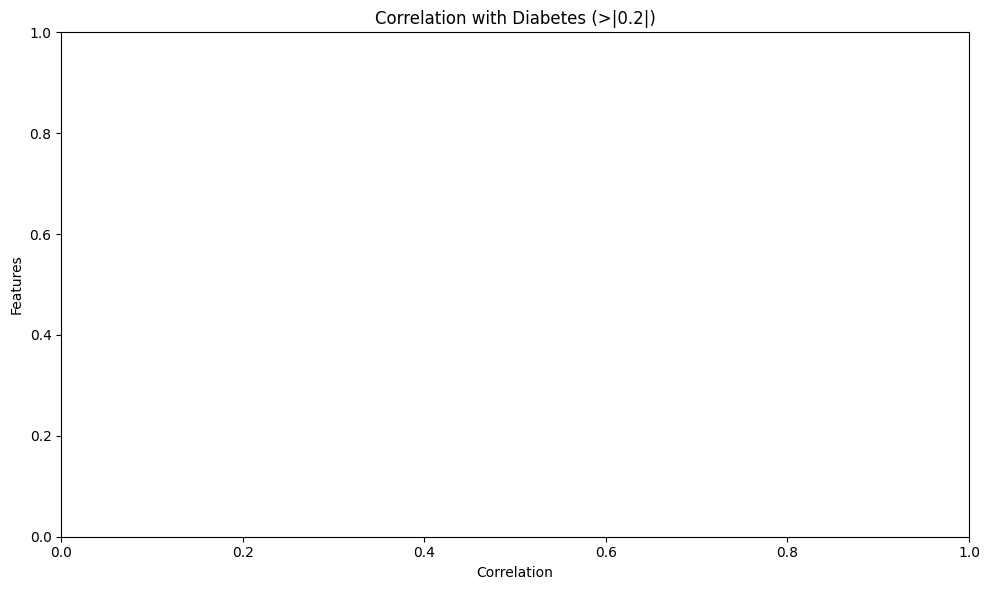

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Select sheet3 columns to include (exclude identifier/date) ---
cols_sheet2 = [col for col in sheet2.columns if col not in ['SubjectID', 'sheet2_Date confirmed']]
data_sheet2 = sheet2[cols_sheet2].copy()

# --- 2. Encode categorical columns in sheet2 ---
data_sheet2_encoded = pd.get_dummies(data_sheet2, drop_first=True)

# --- 3. Select target columns from sheet1 ---
targets = ['High blood pressure', 'Diabetes']

# Make sure target columns exist
for t in targets:
    if t not in sheet1.columns:
        raise ValueError(f"Column '{t}' not found in sheet1!")

# Select the target columns
targets_data = sheet1[targets].copy()

# --- 4. Concatenate sheet2 + targets ---
data_combined = pd.concat([data_sheet2_encoded, targets_data], axis=1)

# --- 5. Compute correlation matrix ---
corr = data_combined.corr()

# --- 6. Filter correlations only with targets and > 0.2 ---
for target in targets:
    # Drop correlations with itself
    corr_target = corr[target].drop(target)
    # Keep only correlations > 0.2 (absolute value)
    corr_target = corr_target[corr_target.abs() > 0.2].sort_values(ascending=False)

    print(f"\nFeatures correlated with {target} (>|0.2|):")
    print(corr_target)

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
    plt.title(f"Correlation with {target} (>|0.2|)")
    plt.xlabel("Correlation")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


## sheet3

In [ ]:
sheet3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   SubjectID                       53 non-null     object        
 1   Sheet3_Date confirmed           52 non-null     datetime64[ns]
 2   Sheet3_Visuospatial cognitive   31 non-null     float64       
 3   Sheet3_Remember                 53 non-null     int64         
 4   Sheet3_use hint                 53 non-null     object        
 5   Sheet3_Reading                  52 non-null     float64       
 6   Sheet3_Calculation              51 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 3.0+ KB


In [ ]:
sheet3.columns

Index(['SubjectID', 'Sheet3_Date confirmed', 'Sheet3_Visuospatial cognitive ',
       'Sheet3_Remember', 'Sheet3_use hint', 'Sheet3_Reading',
       'Sheet3_Calculation'],
      dtype='object')

#### drop

In [ ]:
for column in sheet3.columns:
    if column != "SubjectID":
        unique_values = sheet3[column].dropna().unique()
        if len(unique_values) == 1:
            print(f"Column '{column}' has a single unique value: {unique_values[0]}")

#### unique value

In [ ]:
sheet3['Sheet3_Date confirmed'].fillna(sheet3['Sheet3_Date confirmed'].mode()[0], inplace=True)
sheet3['Sheet3_Date confirmed'].value_counts()

/tmp/ipython-input-3898935077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet3['Sheet3_Date confirmed'].fillna(sheet3['Sheet3_Date confirmed'].mode()[0], inplace=True)
/tmp/ipython-input-3898935077.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet3['Sheet3_Date confirmed'].fillna(sheet3['Sheet3_Date confirmed'].mode()[0], inp

,count
Sheet3_Date confirmed,
2020-12-06,16
2020-12-05,9
2020-12-03,9
2020-12-10,9
2020-12-13,3
2020-12-16,2
2021-01-06,2
2021-02-13,2
2021-01-23,1


In [ ]:
sheet3['Sheet3_Visuospatial cognitive '].fillna(sheet3['Sheet3_Visuospatial cognitive '].mode(), inplace=True)
sheet3['Sheet3_Visuospatial cognitive '].value_counts()

/tmp/ipython-input-4239302313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet3['Sheet3_Visuospatial cognitive '].fillna(sheet3['Sheet3_Visuospatial cognitive '].mode(), inplace=True)
/tmp/ipython-input-4239302313.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet3['Sheet3_Visuospatial cognitive '].fillna(sheet3['Sheet3_Visuosp

,count
Sheet3_Visuospatial cognitive,
3.0,17
2.0,10
1.0,4


In [ ]:
sheet3['Sheet3_Remember'].value_counts()

,count
Sheet3_Remember,
3,26
2,19
1,7
0,1


In [ ]:
sheet3['Sheet3_use hint'].fillna(sheet3['Sheet3_use hint'].mode(), inplace=True)
sheet3['Sheet3_use hint'].value_counts()

/tmp/ipython-input-1171257467.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet3['Sheet3_use hint'].fillna(sheet3['Sheet3_use hint'].mode(), inplace=True)
/tmp/ipython-input-1171257467.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet3['Sheet3_use hint'].fillna(sheet3['Sheet3_use hint'].mode(), inplace=True)


,count
Sheet3_use hint,
no,42
yes,11


In [ ]:
sheet3['Sheet3_Reading'].fillna(sheet3['Sheet3_Reading'].mode()[0], inplace=True)
sheet3['Sheet3_Reading'].value_counts()

/tmp/ipython-input-1139434362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet3['Sheet3_Reading'].fillna(sheet3['Sheet3_Reading'].mode()[0], inplace=True)
/tmp/ipython-input-1139434362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet3['Sheet3_Reading'].fillna(sheet3['Sheet3_Reading'].mode()[0], inplace=True)


,count
Sheet3_Reading,
3.0,43
2.0,7
1.0,2
0.0,1


In [ ]:
sheet3['Sheet3_Calculation'].fillna(sheet3['Sheet3_Calculation'].mode()[0], inplace=True)
sheet3['Sheet3_Calculation'].value_counts()

/tmp/ipython-input-1155621134.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sheet3['Sheet3_Calculation'].fillna(sheet3['Sheet3_Calculation'].mode()[0], inplace=True)
/tmp/ipython-input-1155621134.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet3['Sheet3_Calculation'].fillna(sheet3['Sheet3_Calculation'].mode()[0], inplace=True)


,count
Sheet3_Calculation,
3.0,25
2.0,20
1.0,6
0.0,2


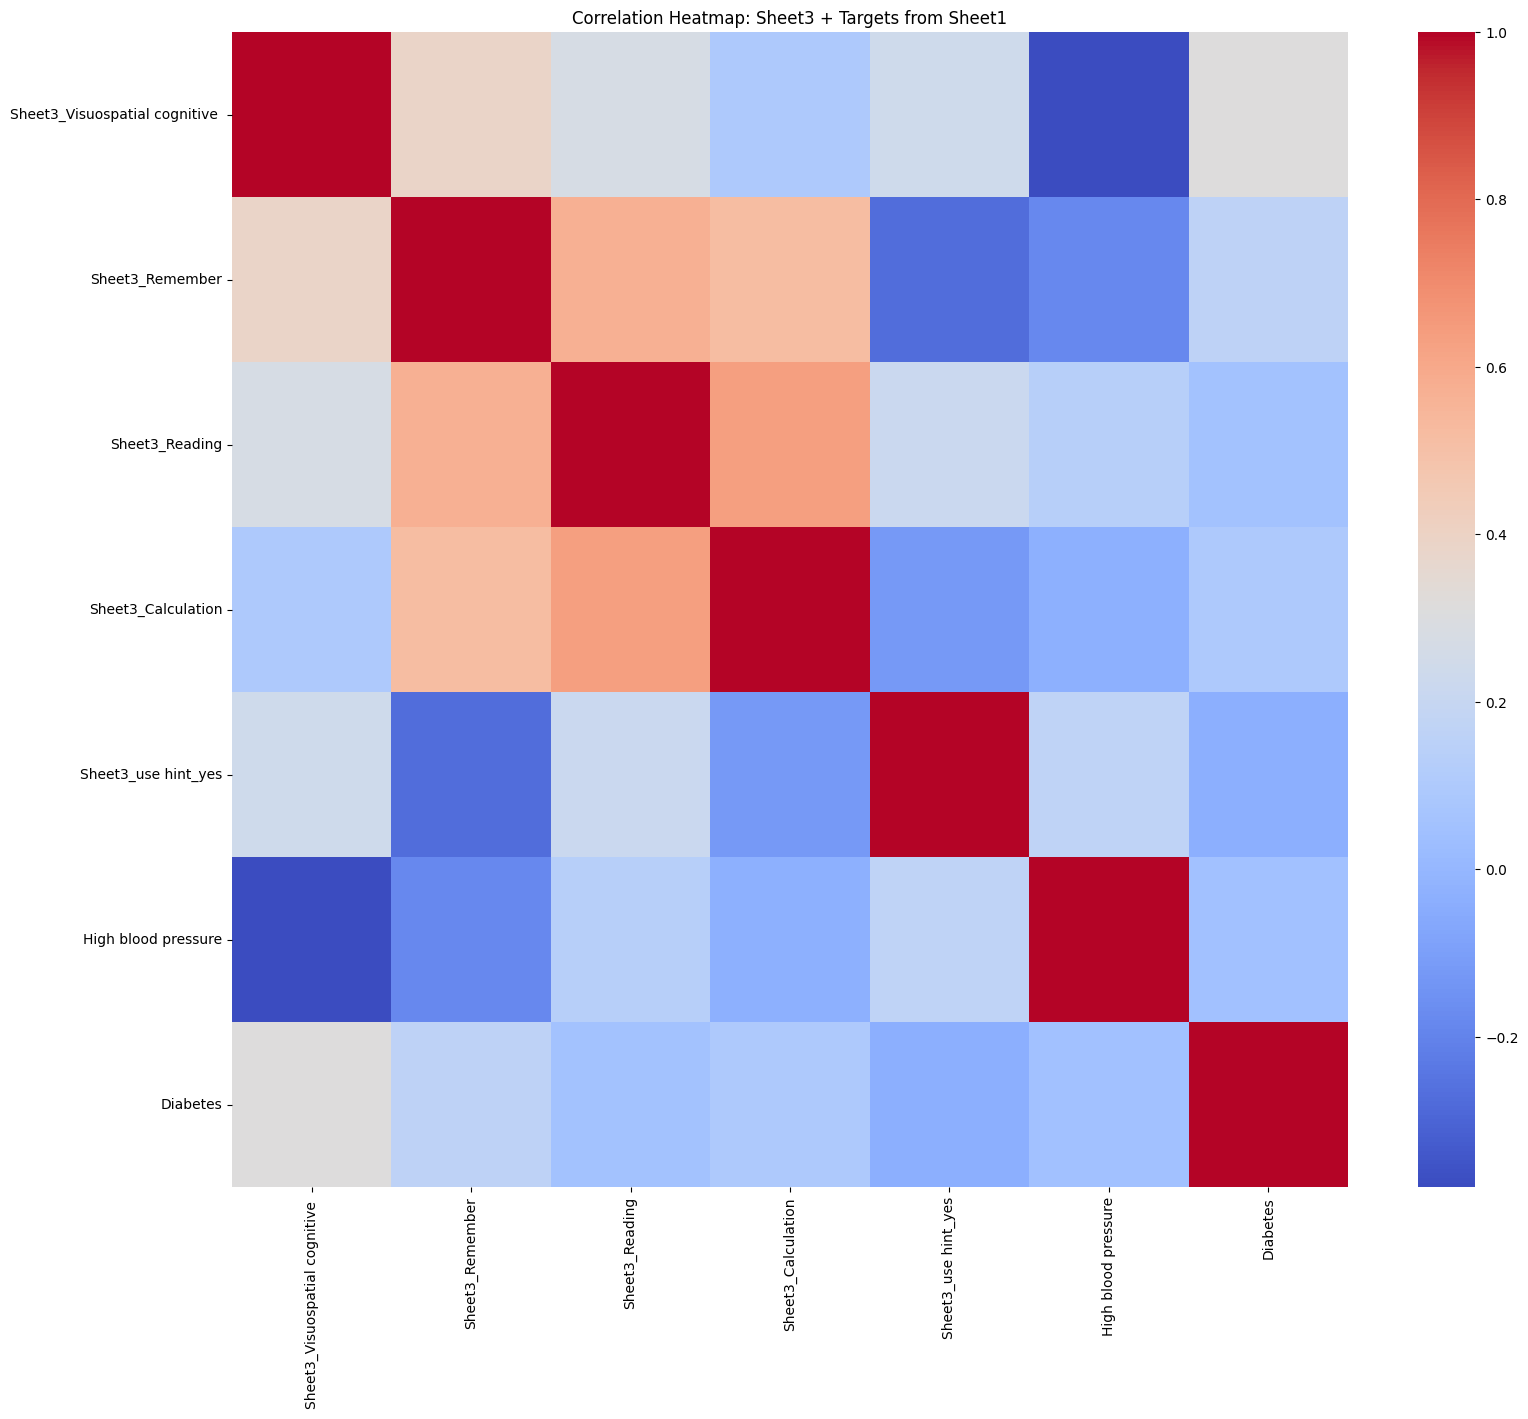

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Select sheet3 columns to include (exclude identifier/date) ---
cols_sheet3 = [col for col in sheet3.columns if col not in ['SubjectID', 'Sheet3_Date confirmed']]
data_sheet3 = sheet3[cols_sheet3].copy()

# --- 2. Encode categorical columns in sheet3 ---
data_sheet3_encoded = pd.get_dummies(data_sheet3, drop_first=True)

# --- 3. Select target columns from sheet1 ---
targets = ['High blood pressure', 'Diabetes']

# Make sure target columns exist
for t in targets:
    if t not in sheet1.columns:
        raise ValueError(f"Column '{t}' not found in sheet1!")

# Select the target columns
targets_data = sheet1[targets].copy()

# --- 4. Concatenate sheet3 + targets ---
data_combined = pd.concat([data_sheet3_encoded, targets_data], axis=1)

# --- 5. Compute correlation matrix ---
corr = data_combined.corr()

# --- 6. Plot heatmap ---
plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap: Sheet3 + Targets from Sheet1")
plt.show()



Features correlated with High blood pressure (>|0.2|):
Sheet3_Visuospatial cognitive    -0.379443
Name: High blood pressure, dtype: float64


/tmp/ipython-input-21733805.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


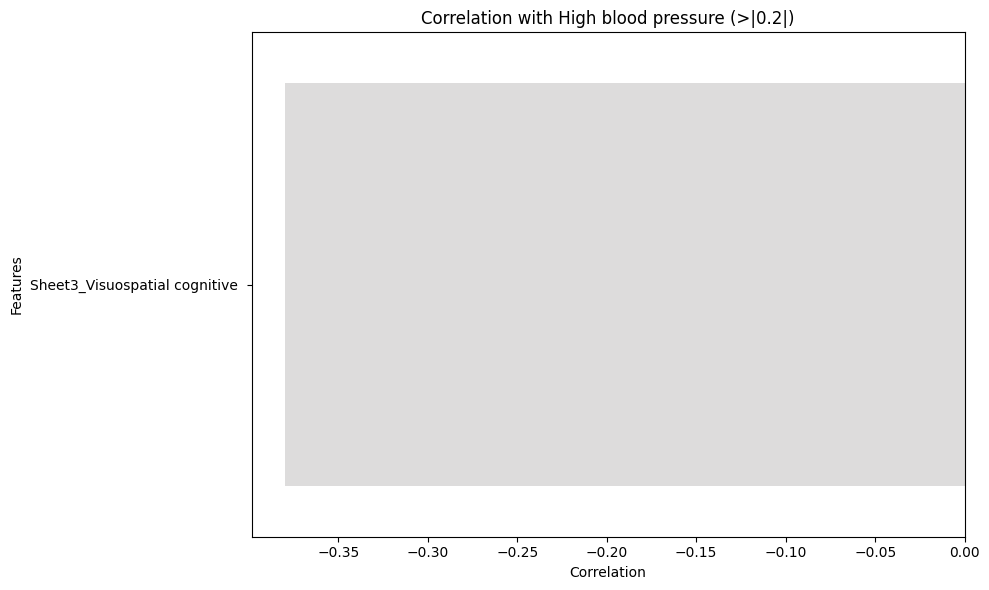


Features correlated with Diabetes (>|0.2|):
Sheet3_Visuospatial cognitive     0.315571
Name: Diabetes, dtype: float64


/tmp/ipython-input-21733805.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")


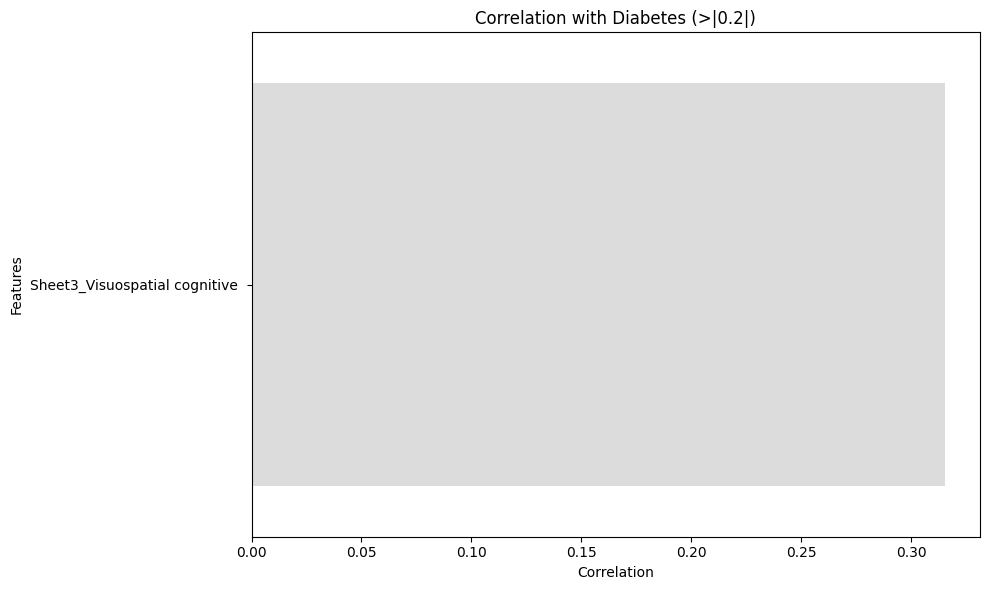

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Select sheet3 columns to include (exclude identifier/date) ---
cols_sheet3 = [col for col in sheet3.columns if col not in ['SubjectID', 'sheet3_Date confirmed']]
data_sheet3 = sheet3[cols_sheet3].copy()

# --- 2. Encode categorical columns in sheet3 ---
data_sheet3_encoded = pd.get_dummies(data_sheet3, drop_first=True)

# --- 3. Select target columns from sheet1 ---
targets = ['High blood pressure', 'Diabetes']

# Make sure target columns exist
for t in targets:
    if t not in sheet1.columns:
        raise ValueError(f"Column '{t}' not found in sheet1!")

# Select the target columns
targets_data = sheet1[targets].copy()

# --- 4. Concatenate sheet3 + targets ---
data_combined = pd.concat([data_sheet3_encoded, targets_data], axis=1)

# --- 5. Compute correlation matrix ---
corr = data_combined.corr()

# --- 6. Filter correlations only with targets and > 0.2 ---
for target in targets:
    # Drop correlations with itself
    corr_target = corr[target].drop(target)
    # Keep only correlations > 0.2 (absolute value)
    corr_target = corr_target[corr_target.abs() > 0.2].sort_values(ascending=False)

    print(f"\nFeatures correlated with {target} (>|0.2|):")
    print(corr_target)

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
    plt.title(f"Correlation with {target} (>|0.2|)")
    plt.xlabel("Correlation")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


## combine sheet1-4

In [ ]:
sheet1to4 = sheet1.merge(sheet2, on='SubjectID', how='outer') \
            .merge(sheet3, on='SubjectID', how='outer') \
            .merge(sheet4, on='SubjectID', how='outer')

## sheet4

In [ ]:
sheet4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SubjectID                 53 non-null     object        
 1   Sheet4_inspection record  53 non-null     object        
 2   Sheet4_Inspection date    16 non-null     datetime64[ns]
 3   Sheet4_Total cholesterol  16 non-null     object        
 4   Sheet4_LDL cholesterol    15 non-null     object        
 5   Sheet4_HDL cholesterol    15 non-null     object        
 6   Sheet4_Urea nitrogen      14 non-null     object        
 7   Sheet4_Creatinine         15 non-null     float64       
 8   Sheet4_Uric acid          16 non-null     object        
 9   Sheet4_Blood sugar        12 non-null     float64       
 10  Sheet4_HbA1c              13 non-null     object        
 11  Sheet4_AST                16 non-null     object        
 12  Sheet4_ALT              

In [ ]:
sheet4['Sheet4_inspection record'].value_counts()

,count
Sheet4_inspection record,
absence,37
presence,16


## sheet5

In [ ]:
sheet5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   SubjectID                   53 non-null     object
 1   Sheet5_Health status        29 non-null     object
 2   Sheet5_Biological function  29 non-null     object
 3   Sheet5_Exercise function    29 non-null     object
 4   Sheet5_Nutrition            29 non-null     object
 5   Sheet5_Cognitive function   29 non-null     object
 6   Sheet5_Fall                 29 non-null     object
 7   Sheet5_High blood pressure  29 non-null     object
 8   Sheet5_Arrhythmia           29 non-null     object
 9   Sheet5_Osteoporosis         29 non-null     object
 10  Sheet5_Diabetes mellitus    29 non-null     object
 11  Sheet5_Exercise guidance    29 non-null     object
 12  Sheet5_Nutrition guidance   29 non-null     object
 13  Sheet5_Life guidance        29 non-null     object
d

## heatmap

In [ ]:
NCDs = [
    'Diabetes',
    'Diabetes mellitus',
    'High blood pressure',
    'Hypercholesterolemia',
    'Hyperlipidemia',
    'Kidney disease',
    'Heart disease (during stent insertion)',
    # 'Cerebral infarction',
    # 'Benign prostatic hypoplasiaer',
    'Cancer (during chemotherapy)',
    'Lung cancer',
    'Lung cancer（2015surgery）',
    'Osteoarthritis of both knees (after surgery)',
    'Neuralgia',
    'Uterine fibroid',
    'arrhythmia'
]

In [ ]:
for df in [sheet1, sheet2, sheet3, sheet4, sheet5]:
    df.columns = df.columns.str.strip()
numeric_cols = ['Sheet4_Total cholesterol','Sheet4_LDL cholesterol','Sheet4_HDL cholesterol',
                'Sheet4_Urea nitrogen','Sheet4_HbA1c','Sheet4_AST','Sheet4_ALT','Sheet4_LDH',
                'Sheet4_Na','Sheet4_K','Sheet4_Triglyceride','Sheet4_Total protein','Sheet4_Albumin']

for col in numeric_cols:
    sheet4[col] = pd.to_numeric(sheet4[col], errors='coerce')
for df in [sheet1, sheet2, sheet3, sheet4, sheet5]:
    for col in df.select_dtypes(include='object').columns:
        df[col] = pd.factorize(df[col])[0]

/tmp/ipython-input-1574048224.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sheet4[col] = pd.to_numeric(sheet4[col], errors='coerce')
/tmp/ipython-input-1574048224.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.factorize(df[col])[0]
/tmp/ipython-input-1574048224.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

In [ ]:
combined_df = sheet1.merge(sheet2, on='SubjectID', how='outer') \
                    .merge(sheet3, on='SubjectID', how='outer') \
                    .merge(sheet4, on='SubjectID', how='outer') \
                    .merge(sheet5, on='SubjectID', how='outer')

In [ ]:
combined_df

,SubjectID,Sheet1_House Type,Sheet1_Gender,Sheet1_Age,Sheet1_Number of residents,Sheet1_Height,Sheet1_Body weight,Sheet1_Stride（cm),Sheet1_Medical history,Sheet1_Regular hospital consultation,Sheet1_Drinking,Sheet1_Hobby,Sheet1_Walking Per Day (minutes),Sheet1_Community,Sheet1_Everyday\nWith or without weight measurement,Sheet1_Everyday With or without blood pressure measurement,Sheet1_Whether or not to use a pedometer on a daily basis,Sheet1_One-legged standing test with eyes open（right）,Sheet1_Alone_or_Not,Sheet1_BMI,Sheet1_BMI Level,Benign prostatic hypplasiaer,Cancer (during chemotherapy),Diabetes,Heart disease (during stent insertion),High blood pressure,Hypercholesterolemia,Hyperlipidemia,Kidney disease,Lung cancer,Lung cancer(2015surgery),Neuralgia,Osteoarthritis of both knees (after surgery),Uterine fibroid,arrhythmia,cerebral infarction,nan,AdalatＣＲ,Amlodipine,Antihypertensive,Azilva,Calblock,Glactiv,Micardis,Nifedipine,NifedipineCR,Olmesartan,Pisoprolol fumarate,Preminent,Trichlormethazide,Trichlormethiazide,Valsartan,,Glactiv,Gractive,Junuvia,Metformin,Metoformin hydrochloride,Repaglinide,Suglat,Tenelia,Antebate,Atorvastatin,Bersolam,Bezafibrate,Crestor,Donepezil,Estarosam,Etizolam,Famotidine,Febrik,Fluvastatin,Full Bath Titanium,Gaster,Halcyon,Lepamidine,Lervea 200 Ellipta 30 for inhalation,Lipitor,Loxoprofen,Magmit,Magnesium Oxide,Magnesium oxide,Mediconic Acid,Montelukast,Mysley,Rebamipide,Rivalo,Rosuvastatin,Sennoside,Silodosin,Tsumura Kakkonto extract,Ttriazolam,Tumura Kampo Kakkonto,Zopiclone,Sheet2_Date confirmed,Sheet2_Appetite,Sheet2_Eating habit,Sheet2_Preference,Sheet2_Sleep,Sheet2_Anxiety about health,Sheet2_Anxiety about forgetfulness,Sheet2_Walking,Sheet2_life,Sheet2_food,Sheet3_Date confirmed,Sheet3_Visuospatial cognitive,Sheet3_Remember,Sheet3_use hint,Sheet3_Reading,Sheet3_Calculation,Sheet4_inspection record,Sheet4_Inspection date,Sheet4_Total cholesterol,Sheet4_LDL cholesterol,Sheet4_HDL cholesterol,Sheet4_Urea nitrogen,Sheet4_Creatinine,Sheet4_Uric acid,Sheet4_Blood sugar,Sheet4_HbA1c,Sheet4_AST,Sheet4_ALT,Sheet4_LDH,Sheet4_Na,Sheet4_K,Sheet4_ECG abnormalities,Sheet4_Triglyceride,Sheet4_Total protein,Sheet4_Albumin,Sheet5_Health status,Sheet5_Biological function,Sheet5_Exercise function,Sheet5_Nutrition,Sheet5_Cognitive function,Sheet5_Fall,Sheet5_High blood pressure,Sheet5_Arrhythmia,Sheet5_Osteoporosis,Sheet5_Diabetes mellitus,Sheet5_Exercise guidance,Sheet5_Nutrition guidance,Sheet5_Life guidance
0,0,0,0,74,3,145.0,39.0,35.000000,0,0,0,0,60.0,0,0,0,0,0,0,18.549346,Normal,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,2020-11-25,0,3,0,0,0,0,0,0,0,2020-12-05,2.0,2,0,3.0,2.0,0,NaT,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,73,2,155.0,50.0,44.000000,0,0,0,1,60.0,1,1,1,0,0,0,20.811655,Normal,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2020-11-23,0,3,0,0,0,0,0,0,0,2020-12-05,3.0,3,1,3.0,3.0,1,2020-11-29,150.0,86.0,39.0,NaN,1.11,0,108.0,6.2,24.0,20.0,112.0,NaN,NaN,-1,153.0,7.7,5.0,0,0,1,1,0,0,1,0,1,1,1,1,1
2,2,0,0,76,2,154.0,56.5,26.900000,0,0,0,1,60.0,2,1,1,1,0,0,23.823579,Normal,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2020-11-25,1,3,0,0,0,0,0,0,0,2020-12-05,1.0,2,1,3.0,3.0,1,2020-08-04,260.0,163.0,68.0,20.3,0.75,1,NaN,NaN,18.0,12.0,175.0,142.0,3.50,-1,NaN,7.2,NaN,0,0,1,1,1,0,0,0,0,0,1,1,0
3,3,0,1,81,2,158.0,65.0,32.300000,0,0,1,1,0.0,2,1,0,0,1,0,26.037494,Overweight,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-11-25,0,3,1,0,1,0,0,1,0,2020-12-05,2.0,2,1,3.0,2.0,1,2020-09-02,NaN,NaN,NaN,37.5,3.57,2,NaN,5.0,NaN,NaN,NaN,147.0,4.85,-1,NaN,6.3

In [ ]:
import pandas as pd

# สมมติ combined_df คือ DataFrame ของคุณ

# แปลงทุกคอลัมน์ object เป็นตัวเลขอัตโนมัติ
for col in combined_df.select_dtypes(include='object').columns:
    combined_df[col] = pd.factorize(combined_df[col])[0]

# ตรวจสอบผลลัพธ์
combined_df.head()



,SubjectID,Sheet1_House Type,Sheet1_Gender,Sheet1_Age,Sheet1_Number of residents,Sheet1_Height,Sheet1_Body weight,Sheet1_Stride（cm),Sheet1_Medical history,Sheet1_Regular hospital consultation,Sheet1_Drinking,Sheet1_Hobby,Sheet1_Walking Per Day (minutes),Sheet1_Community,Sheet1_Everyday\nWith or without weight measurement,Sheet1_Everyday With or without blood pressure measurement,Sheet1_Whether or not to use a pedometer on a daily basis,Sheet1_One-legged standing test with eyes open（right）,Sheet1_Alone_or_Not,Sheet1_BMI,Sheet1_BMI Level,Benign prostatic hypplasiaer,Cancer (during chemotherapy),Diabetes,Heart disease (during stent insertion),High blood pressure,Hypercholesterolemia,Hyperlipidemia,Kidney disease,Lung cancer,Lung cancer(2015surgery),Neuralgia,Osteoarthritis of both knees (after surgery),Uterine fibroid,arrhythmia,cerebral infarction,nan,AdalatＣＲ,Amlodipine,Antihypertensive,Azilva,Calblock,Glactiv,Micardis,Nifedipine,NifedipineCR,Olmesartan,Pisoprolol fumarate,Preminent,Trichlormethazide,Trichlormethiazide,Valsartan,,Glactiv,Gractive,Junuvia,Metformin,Metoformin hydrochloride,Repaglinide,Suglat,Tenelia,Antebate,Atorvastatin,Bersolam,Bezafibrate,Crestor,Donepezil,Estarosam,Etizolam,Famotidine,Febrik,Fluvastatin,Full Bath Titanium,Gaster,Halcyon,Lepamidine,Lervea 200 Ellipta 30 for inhalation,Lipitor,Loxoprofen,Magmit,Magnesium Oxide,Magnesium oxide,Mediconic Acid,Montelukast,Mysley,Rebamipide,Rivalo,Rosuvastatin,Sennoside,Silodosin,Tsumura Kakkonto extract,Ttriazolam,Tumura Kampo Kakkonto,Zopiclone,Sheet2_Date confirmed,Sheet2_Appetite,Sheet2_Eating habit,Sheet2_Preference,Sheet2_Sleep,Sheet2_Anxiety about health,Sheet2_Anxiety about forgetfulness,Sheet2_Walking,Sheet2_life,Sheet2_food,Sheet3_Date confirmed,Sheet3_Visuospatial cognitive,Sheet3_Remember,Sheet3_use hint,Sheet3_Reading,Sheet3_Calculation,Sheet4_inspection record,Sheet4_Inspection date,Sheet4_Total cholesterol,Sheet4_LDL cholesterol,Sheet4_HDL cholesterol,Sheet4_Urea nitrogen,Sheet4_Creatinine,Sheet4_Uric acid,Sheet4_Blood sugar,Sheet4_HbA1c,Sheet4_AST,Sheet4_ALT,Sheet4_LDH,Sheet4_Na,Sheet4_K,Sheet4_ECG abnormalities,Sheet4_Triglyceride,Sheet4_Total protein,Sheet4_Albumin,Sheet5_Health status,Sheet5_Biological function,Sheet5_Exercise function,Sheet5_Nutrition,Sheet5_Cognitive function,Sheet5_Fall,Sheet5_High blood pressure,Sheet5_Arrhythmia,Sheet5_Osteoporosis,Sheet5_Diabetes mellitus,Sheet5_Exercise guidance,Sheet5_Nutrition guidance,Sheet5_Life guidance
0,0,0,0,74,3,145.0,39.0,35.0,0,0,0,0,60.0,0,0,0,0,0,0,18.549346,Normal,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,2020-11-25,0,3,0,0,0,0,0,0,0,2020-12-05,2.0,2,0,3.0,2.0,0,NaT,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,73,2,155.0,50.0,44.0,0,0,0,1,60.0,1,1,1,0,0,0,20.811655,Normal,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2020-11-23,0,3,0,0,0,0,0,0,0,2020-12-05,3.0,3,1,3.0,3.0,1,2020-11-29,150.0,86.0,39.0,NaN,1.11,0,108.0,6.2,24.0,20.0,112.0,NaN,NaN,-1,153.0,7.7,5.0,0,0,1,1,0,0,1,0,1,1,1,1,1
2,2,0,0,76,2,154.0,56.5,26.9,0,0,0,1,60.0,2,1,1,1,0,0,23.823579,Normal,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2020-11-25,1,3,0,0,0,0,0,0,0,2020-12-05,1.0,2,1,3.0,3.0,1,2020-08-04,260.0,163.0,68.0,20.3,0.75,1,NaN,NaN,18.0,12.0,175.0,142.0,3.50,-1,NaN,7.2,NaN,0,0,1,1,1,0,0,0,0,0,1,1,0
3,3,0,1,81,2,158.0,65.0,32.3,0,0,1,1,0.0,2,1,0,0,1,0,26.037494,Overweight,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2020-11-25,0,3,1,0,1,0,0,1,0,2020-12-05,2.0,2,1,3.0,2.0,1,2020-09-02,NaN,NaN,NaN,37.5,3.57,2,NaN,5.0,NaN,NaN,NaN,147.0,4.85,-1,NaN,6.3,4.2,1,1,1,0,1,0,0,0

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


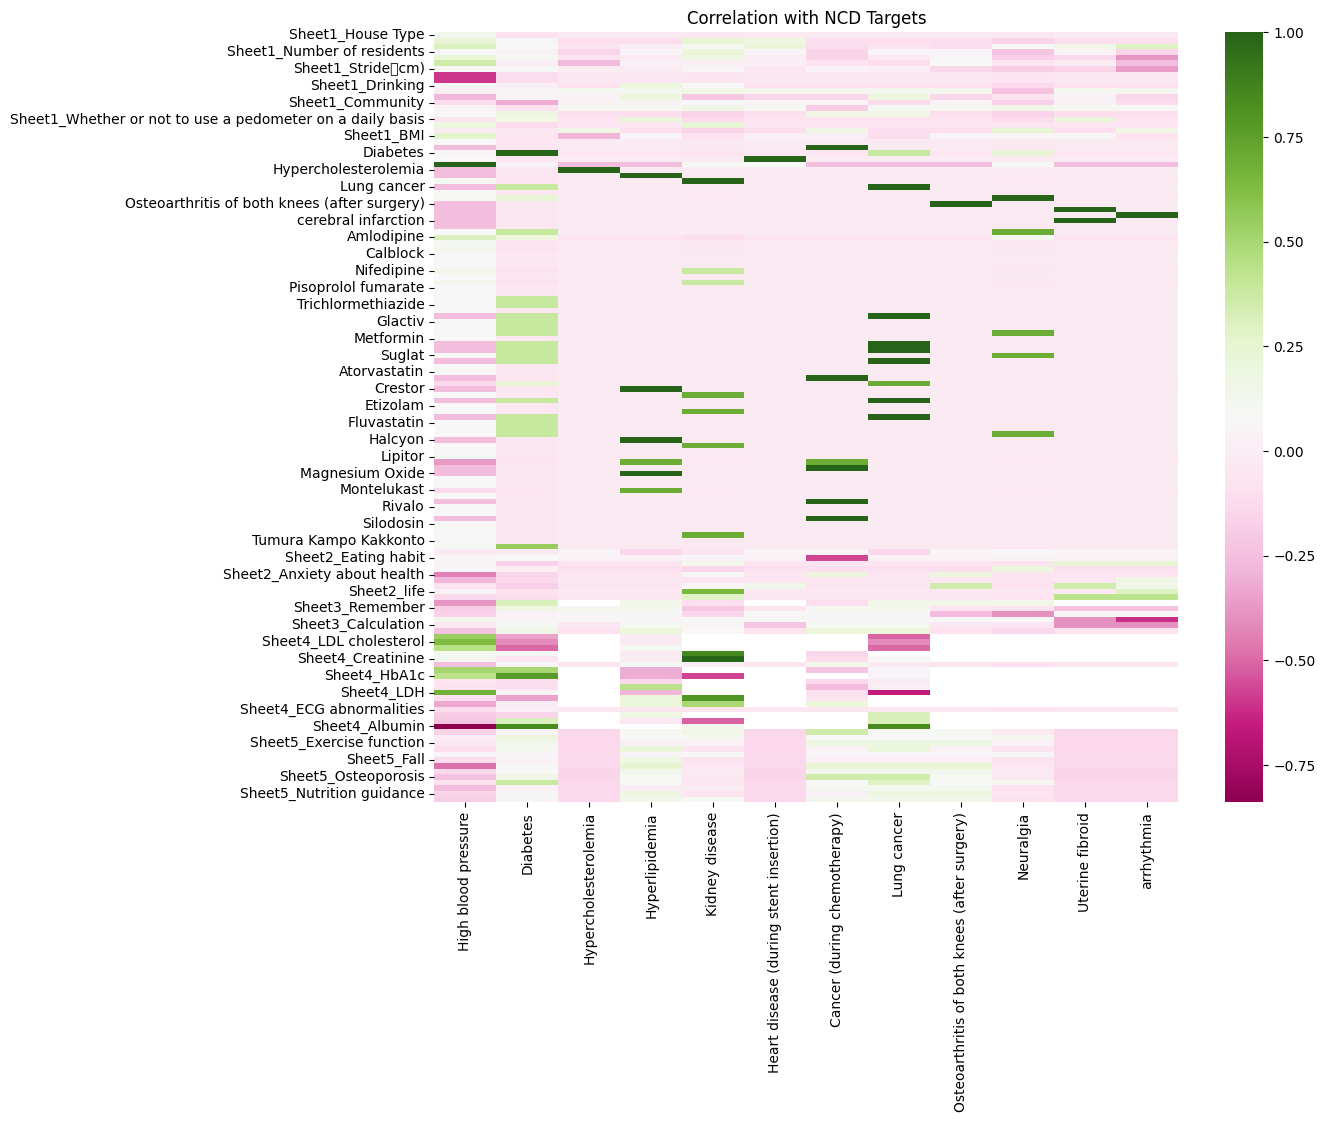

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# เลือกเฉพาะ numeric columns
numeric_df = combined_df.select_dtypes(include=['int64', 'float64', 'float32', 'int32'])
numeric_df = numeric_df.drop(columns=['SubjectID'], errors='ignore')

# คำนวณ correlation
corr = numeric_df.corr()

# ระบุ target
targets = ['High blood pressure','Diabetes', 'Hypercholesterolemia',
           'Hyperlipidemia', 'Kidney disease', 'Heart disease (during stent insertion)',
           'Cancer (during chemotherapy)', 'Lung cancer', 'Osteoarthritis of both knees (after surgery)',
           'Neuralgia','Uterine fibroid',
           'arrhythmia']

# เลือก correlation กับ targets
corr_targets = corr[targets]

# วาด heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_targets, cmap='PiYG', cbar=True)
plt.title("Correlation with NCD Targets")
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


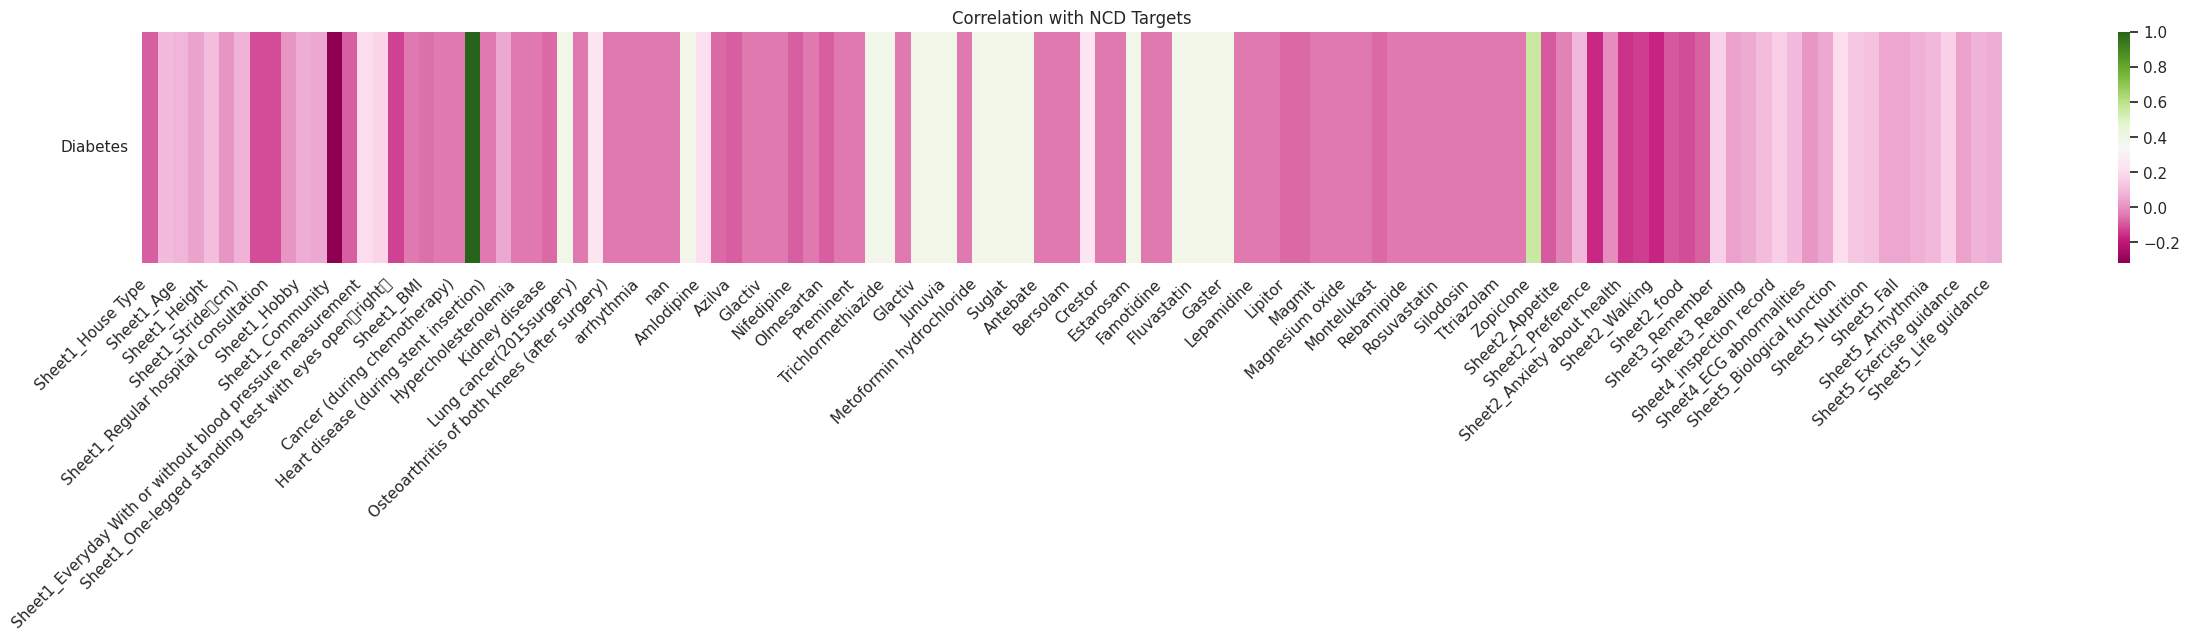

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# เลือกเฉพาะ numeric columns
numeric_df = combined_df.select_dtypes(include=['int64', 'float64', 'float32', 'int32'])
numeric_df = numeric_df.drop(columns=['SubjectID'], errors='ignore')

# คำนวณ correlation
corr = numeric_df.corr()

# ระบุ target
targets = ['Diabetes']

# เลือก correlation กับ targets
corr_targets = corr[targets]

# วาด heatmap
plt.figure(figsize=(30, 3))
sns.heatmap(corr_targets.T, cmap='PiYG', cbar=True)
plt.xticks(rotation=45, ha='right')   # เอียง 45°
plt.yticks(rotation=0)                # ไม่เอียงแกน y
plt.title("Correlation with NCD Targets")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ดึง correlation กับ Diabetes
corr_series = corr['Diabetes'].drop('Diabetes', errors='ignore')
corr_series = corr_series[corr_series.index.str.strip() != ""]  # ตัดชื่อว่าง ""

# เลือก correlation ที่มากกว่า threshold

threshold = 0.2  # ปรับได้
high_corr = corr_series[abs(corr_series) > threshold]

# เตรียม colormap (เหมือน heatmap)
cmap = plt.cm.get_cmap("PiYG")
norm = mpl.colors.Normalize(vmin=high_corr.min(), vmax=high_corr.max())
colors = cmap(norm(high_corr.values))

plt.figure(figsize=(16, 10))
plt.bar(high_corr.index, high_corr.values, color=colors)  # ใช้สีจาก colormap

plt.xticks(rotation=45, ha='right', fontsize=14)   # ตัวแปรแกน X
plt.ylabel("Correlation")
plt.title(f"High Correlations with Diabetes (>|{threshold}|)")
plt.tight_layout()
plt.show()


KeyError: 'SubjectID'

## train

In [ ]:
combined_df['Diabetes'].value_counts()

,count
Diabetes,
0,47
1,6


In [ ]:
combined_df = combined_df.drop(columns=['SubjectID','Sheet5_Diabetes mellitus'], errors='ignore')

In [ ]:
combined_df.head()

,Sheet1_House Type,Sheet1_Gender,Sheet1_Age,Sheet1_Number of residents,Sheet1_Height,Sheet1_Body weight,Sheet1_Stride（cm),Sheet1_Medical history,Sheet1_Regular hospital consultation,Sheet1_Drinking,Sheet1_Hobby,Sheet1_Walking Per Day (minutes),Sheet1_Community,Sheet1_Everyday\nWith or without weight measurement,Sheet1_Everyday With or without blood pressure measurement,Sheet1_Whether or not to use a pedometer on a daily basis,Sheet1_One-legged standing test with eyes open（right）,Sheet1_Alone_or_Not,Sheet1_BMI,Sheet1_BMI Level,Benign prostatic hypplasiaer,Cancer (during chemotherapy),Diabetes,Heart disease (during stent insertion),High blood pressure,Hypercholesterolemia,Hyperlipidemia,Kidney disease,Lung cancer,Lung cancer(2015surgery),Neuralgia,Osteoarthritis of both knees (after surgery),Uterine fibroid,arrhythmia,cerebral infarction,nan,AdalatＣＲ,Amlodipine,Antihypertensive,Azilva,Calblock,Glactiv,Micardis,Nifedipine,NifedipineCR,Olmesartan,Pisoprolol fumarate,Preminent,Trichlormethazide,Trichlormethiazide,Valsartan,Glactiv,Gractive,Junuvia,Metformin,Metoformin hydrochloride,Repaglinide,Suglat,Tenelia,Antebate,Atorvastatin,Bersolam,Bezafibrate,Crestor,Donepezil,Estarosam,Etizolam,Famotidine,Febrik,Fluvastatin,Full Bath Titanium,Gaster,Halcyon,Lepamidine,Lervea 200 Ellipta 30 for inhalation,Lipitor,Loxoprofen,Magmit,Magnesium Oxide,Magnesium oxide,Mediconic Acid,Montelukast,Mysley,Rebamipide,Rivalo,Rosuvastatin,Sennoside,Silodosin,Tsumura Kakkonto extract,Ttriazolam,Tumura Kampo Kakkonto,Zopiclone,Sheet2_Date confirmed,Sheet2_Appetite,Sheet2_Eating habit,Sheet2_Preference,Sheet2_Sleep,Sheet2_Anxiety about health,Sheet2_Anxiety about forgetfulness,Sheet2_Walking,Sheet2_life,Sheet2_food,Sheet3_Date confirmed,Sheet3_Remember,Sheet3_use hint,Sheet3_Reading,Sheet3_Calculation,Sheet4_inspection record,Sheet4_Uric acid,Sheet4_ECG abnormalities,Sheet5_Health status,Sheet5_Biological function,Sheet5_Exercise function,Sheet5_Nutrition,Sheet5_Cognitive function,Sheet5_Fall,Sheet5_High blood pressure,Sheet5_Arrhythmia,Sheet5_Osteoporosis,Sheet5_Exercise guidance,Sheet5_Nutrition guidance,Sheet5_Life guidance
0,0,0,74,3,145.0,39.0,35.0,0,0,0,0,60.0,0,0,0,0,0,0,18.549346,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1.606262e+09,0,3,0,0,0,0,0,0,0,1.607126e+09,2,0,3.0,2.0,0,-1,-1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,73,2,155.0,50.0,44.0,0,0,0,1,60.0,1,1,1,0,0,0,20.811655,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.606090e+09,0,3,0,0,0,0,0,0,0,1.607126e+09,3,1,3.0,3.0,1,0,-1,0,0,1,1,0,0,1,0,1,1,1,1
2,0,0,76,2,154.0,56.5,26.9,0,0,0,1,60.0,2,1,1,1,0,0,23.823579,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1.606262e+09,1,3,0,0,0,0,0,0,0,1.607126e+09,2,1,3.0,3.0,1,1,-1,0,0,1,1,1,0,0,0,0,1,1,0
3,0,1,81,2,158.0,65.0,32.3,0,0,1,1,0.0,2,1,0,0,1,0,26.037494,2,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1.606262e+09,0,3,1,0,1,0,0,1,0,1.607126e+09,2,1,3.0,2.0,1,2,-1,1,1,1,0,1,0,0,0,0,1,0,2
4,0,0,77,2,156.0,60.0,41.4,0,0,1,1,60.0,2,1,0,1,0,0,24.654832,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1.606262e+09,0,3,0,0,0,0,0,0,0,1.607126e+09,3,1,3.0,3.0,1,3,-1,0,0,0,1,0,1,1,0,0,0,1,1


In [ ]:
# # ลบคอลัมน์ชื่อว่างหรือ nan
# # X = X.loc[:, X.columns.notna()]        # ตัดคอลัมน์ชื่อ NaN
# X = X.loc[:, X.columns.str.strip() != ""]  # ตัดคอลัมน์ชื่อว่าง

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# =========================
# 1️⃣ ลบคอลัมน์ missing > 40% และ SubjectID
threshold = 0.4
cols_to_drop = combined_df.columns[combined_df.isna().mean() > threshold]
columns_to_remove = list(cols_to_drop) + ['SubjectID']  # ลบ SubjectID ด้วย
combined_df = combined_df.drop(columns=columns_to_remove, errors='ignore')

# =========================
# 2️⃣ แปลง category เป็น numeric
for col in combined_df.select_dtypes(include='category').columns:
    combined_df[col] = combined_df[col].cat.codes

# =========================
# 3️⃣ แปลง datetime เป็น numeric (timestamp)
for col in combined_df.select_dtypes(include='datetime64[ns]').columns:
    combined_df[col] = combined_df[col].astype(int) / 10**9  # แปลงเป็น seconds

# =========================
# 4️⃣ ลบคอลัมน์ชื่อว่างหรือ nan
combined_df = combined_df.loc[:, combined_df.columns.notna()]            # ตัดชื่อ NaN
combined_df = combined_df.loc[:, combined_df.columns.str.strip() != ""]  # ตัดชื่อว่าง ""

# =========================
# 5️⃣ เติม NaN สำหรับ numeric ด้วย median
numeric_cols = combined_df.select_dtypes(include=['int64','float64','float32']).columns
for col in numeric_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())

# =========================
# 6️⃣ เติม NaN สำหรับ categorical (เหลือ object) ด้วย mode
categorical_cols = combined_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if combined_df[col].mode().empty:
        combined_df[col] = combined_df[col].fillna("Unknown")
    else:
        combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

# =========================
# 7️⃣ แยก X / y
target_col = 'Diabetes'  # ปรับชื่อ target ตามต้องการ
X = combined_df.drop(columns=[target_col])
y = combined_df[target_col]

# =========================
# 8️⃣ ทำ SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original dataset shape:", y.value_counts())
print("Resampled dataset shape:", pd.Series(y_resampled).value_counts())


Original dataset shape: Diabetes
0    47
1     6
Name: count, dtype: int64
Resampled dataset shape: Diabetes
0    47
1    47
Name: count, dtype: int64


Random Forest F1-score: 0.923
Logistic Regression F1-score: 0.966
XGBoost F1-score: 0.933

Best Model: Logistic Regression

=== Sample Risk Level Table ===
    Probability  Probability (%)   Risk Level
0      0.068324         6.832433     Low Risk
1      0.001056         0.105602     Low Risk
2      0.966967        96.696730    High Risk
3      0.961183        96.118325    High Risk
4      0.114698        11.469820     Low Risk
5      0.941915        94.191468    High Risk
6      0.006903         0.690253     Low Risk
7      0.017629         1.762892     Low Risk
8      0.604171        60.417126  Medium Risk
9      0.989412        98.941154    High Risk
10     0.074755         7.475478     Low Risk
11     0.844334        84.433406    High Risk
12     0.962660        96.265961    High Risk
13     0.028353         2.835318     Low Risk
14     0.950438        95.043764    High Risk
15     0.963542        96.354191    High Risk
16     0.002441         0.244113     Low Risk
17     0.180826 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:55:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


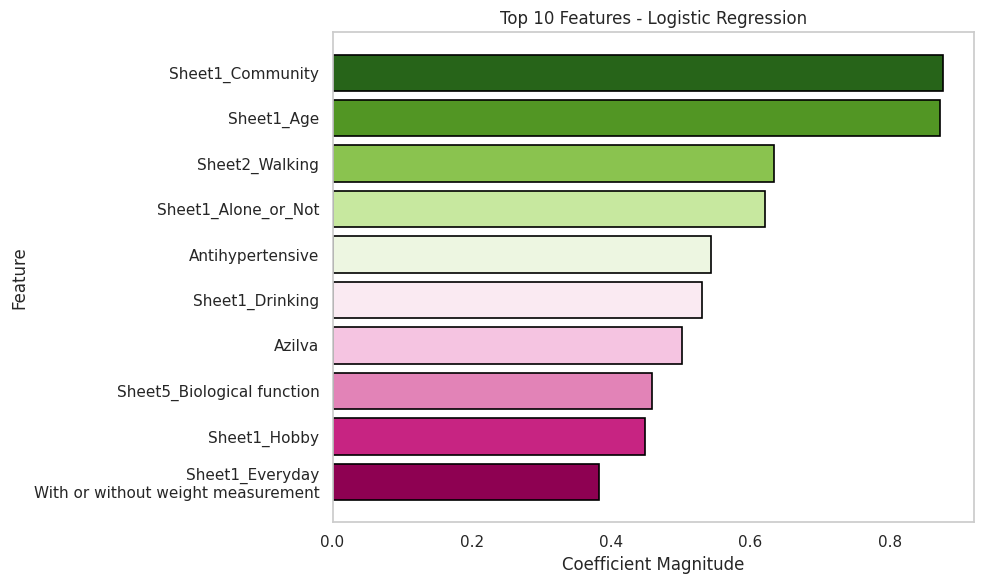


Confusion Matrix:
[[14  1]
 [ 0 14]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      1.00      0.97        14

    accuracy                           0.97        29
   macro avg       0.97      0.97      0.97        29
weighted avg       0.97      0.97      0.97        29



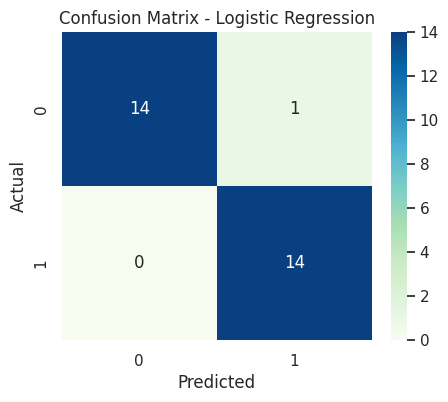

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Ensure all columns are numeric for models that require it
# This step is crucial if previous type conversions were not fully effective

# Apply pd.to_numeric to the entire DataFrame, coercing errors to NaN
X_resampled = X_resampled.apply(pd.to_numeric, errors='coerce')

# Fill any NaNs that might have been introduced by the to_numeric coercion
# using the median for numeric columns
for col in X_resampled.select_dtypes(include=['float64', 'int64']).columns:
    X_resampled[col] = X_resampled[col].fillna(X_resampled[col].median())

# =========================
# 1️⃣ เตรียม Train/Test Split
# X_resampled, y_resampled มาจาก SMOTE แล้ว
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled
)

# =========================
# 2️⃣ เตรียมโมเดล
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Logistic Regression ต้อง scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 3️⃣ Train ทุกโมเดลและคำนวณ F1-score
model_results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Convert DataFrames to NumPy arrays for tree-based models for robustness
        model.fit(X_train.to_numpy().astype(float), y_train)
        y_pred = model.predict(X_test.to_numpy().astype(float))

    f1 = f1_score(y_test, y_pred)
    model_results[name] = {
        "model": model,
        "f1_score": f1,
        "y_pred": y_pred
    }
    print(f"{name} F1-score: {f1:.3f}")

# =========================
# 4️⃣ เลือกโมเดลที่ดีที่สุด
best_model_name = max(model_results, key=lambda x: model_results[x]["f1_score"])
best_model = model_results[best_model_name]["model"]
print(f"\nBest Model: {best_model_name}")

# =========================
# 5️⃣ Probability และ Risk Level
if best_model_name == "Logistic Regression":
    y_prob = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_prob = best_model.predict_proba(X_test.to_numpy().astype(float))[:,1]

def diabetes_risk_level(prob):
    if prob <= 0.29:
        return "Low Risk"
    elif prob <= 0.69:
        return "Medium Risk"
    else:
        return "High Risk"

df_risk = pd.DataFrame({
    "Probability": y_prob,
    "Probability (%)": y_prob*100
})
df_risk["Risk Level"] = df_risk["Probability"].apply(diabetes_risk_level)

print("\n=== Sample Risk Level Table ===")
print(df_risk)

# =========================
# 6️⃣ Top 10 Features (Color: PiYG)
if best_model_name in ["Random Forest", "XGBoost"]:
    feat_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_features = feat_importances.sort_values(ascending=False).head(10)

    print("\nTop 10 Features:")
    print(top_features)

    # ---- ใช้ PiYG colormap ----
    cmap = plt.get_cmap("GnBu")
    colors = cmap(np.linspace(0, 1, len(top_features)))

    top_features.sort_values().plot(
        kind='barh',
        figsize=(10,6),
        color=colors
    )
    plt.title(f"Top 10 Features - {best_model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.show()

elif best_model_name == "Logistic Regression":
    coef = pd.Series(abs(best_model.coef_[0]), index=X_train.columns)
    top_features = coef.sort_values(ascending=False).head(10)

    print("\nTop 10 Features (abs coef):")
    print(top_features)

    # ---- ใช้ ocean colormap ----
    cmap = plt.get_cmap("PiYG")
    colors = cmap(np.linspace(0, 1, len(top_features)))

    plt.figure(figsize=(10,6))
    ax = plt.gca()

    # วาด barh แบบ custom → เพื่อกำหนด edgecolor ได้
    ax.barh(
        top_features.sort_values().index,
        top_features.sort_values().values,
        color=colors,
        edgecolor="black",      # 🔥 ขอบสีดำของแท่งกราฟ
        linewidth=1.2
    )

    # ลบเส้น grid
    ax.grid(False)

    plt.title(f"Top 10 Features - {best_model_name}")
    plt.xlabel("Coefficient Magnitude")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


# =========================
# 7️⃣ Confusion Matrix
y_pred_best = best_model.predict(X_test_scaled if best_model_name=="Logistic Regression" else X_test.to_numpy().astype(float))
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


/tmp/ipython-input-117782293.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


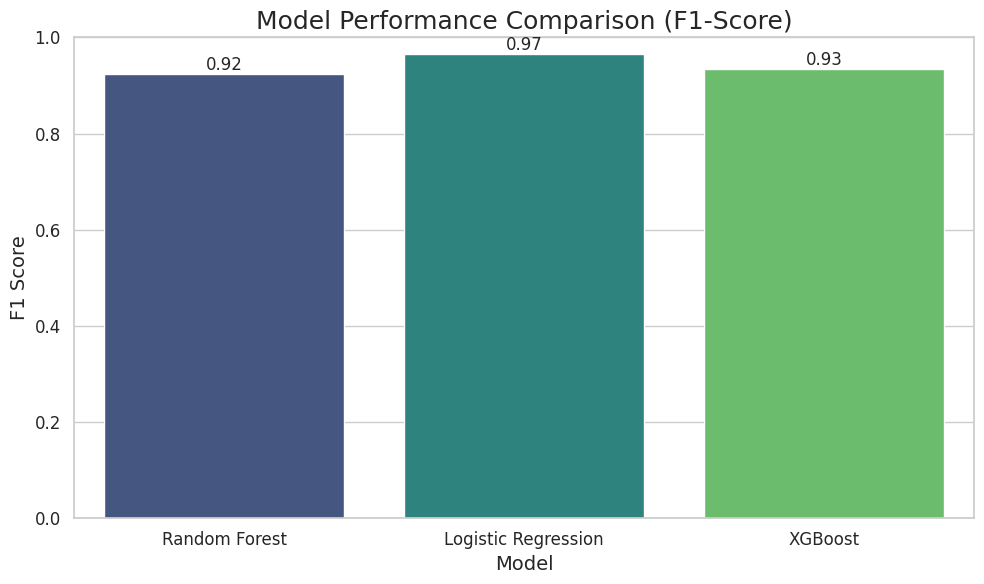

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ให้ seaborn ใช้ style สวย ๆ
sns.set(style="whitegrid")

# ============================
# 1) เตรียมข้อมูลสำหรับกราฟ
# ============================
model_names = list(model_results.keys())
f1_scores = [model_results[m]["f1_score"] for m in model_names]

performance_df = pd.DataFrame({
    "Model": model_names,
    "F1 Score": f1_scores
})

# ============================
# 2) Plot Graph
# ============================
plt.figure(figsize=(10,6))
bars = sns.barplot(
    x="Model",
    y="F1 Score",
    data=performance_df,
    palette="viridis"
)

# ติดค่า F1 บนหัวแท่งกราฟ
for p in bars.patches:
    bars.annotate(f"{p.get_height():.2f}",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12)

plt.ylim(0,1)
plt.title("Model Performance Comparison (F1-Score)", fontsize=18)
plt.xlabel("Model", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
df_risk

,Probability,Probability (%),Risk Level
0,0.068324,6.832433,Low Risk
1,0.001056,0.105602,Low Risk
2,0.966967,96.696730,High Risk
3,0.961183,96.118325,High Risk
4,0.114698,11.469820,Low Risk
5,0.941915,94.191468,High Risk
6,0.006903,0.690253,Low Risk
7,0.017629,1.762892,Low Risk
8,0.604171,60.417126,Medium Risk
9,0.989412,98.941154,High Risk
